<a href="https://colab.research.google.com/github/MonikSense/GAAFET/blob/main/GAAFinal-J3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

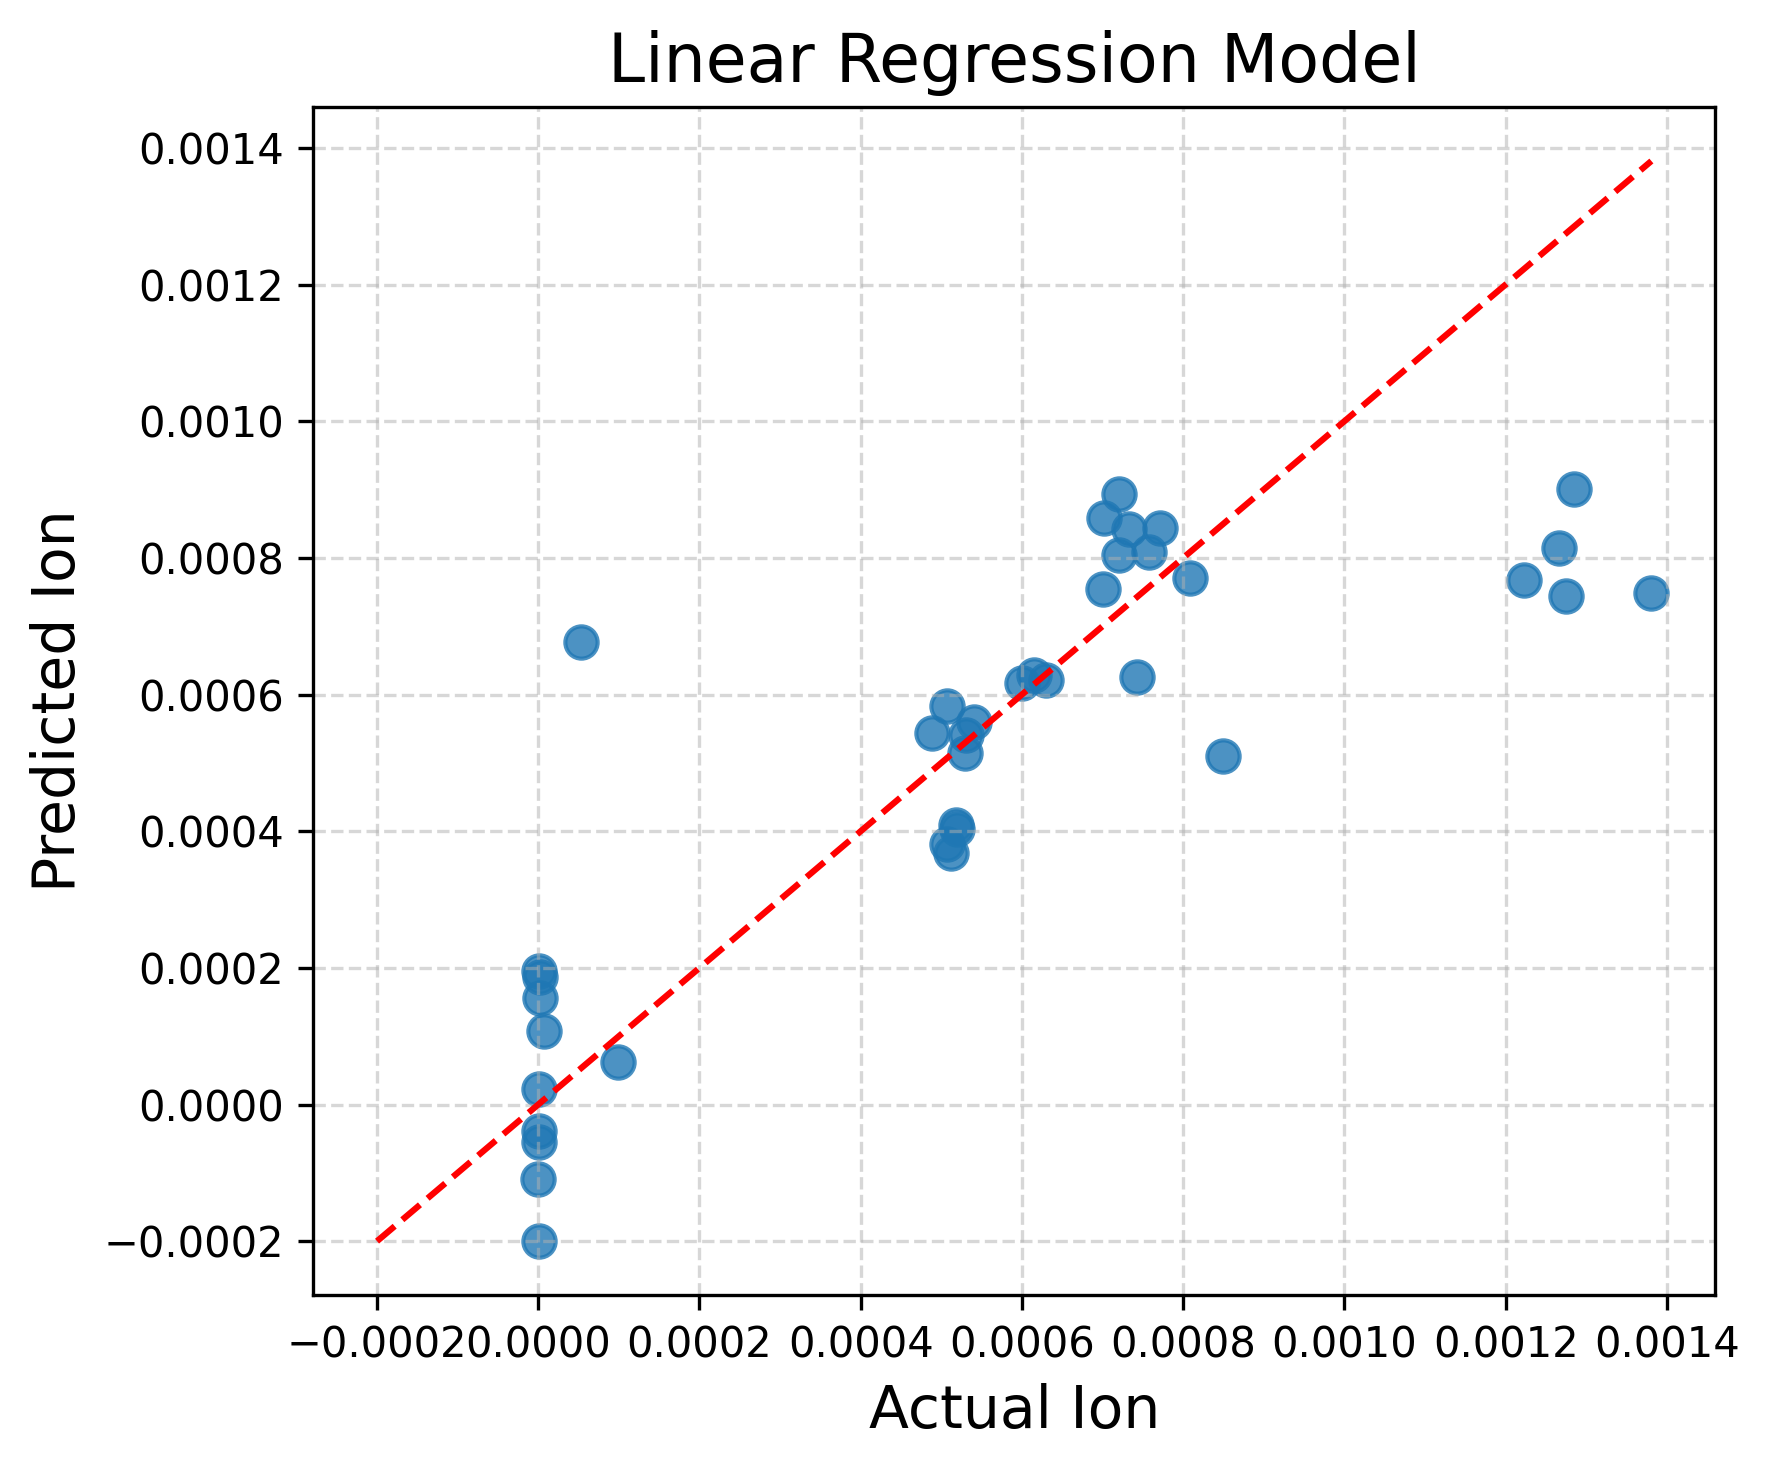

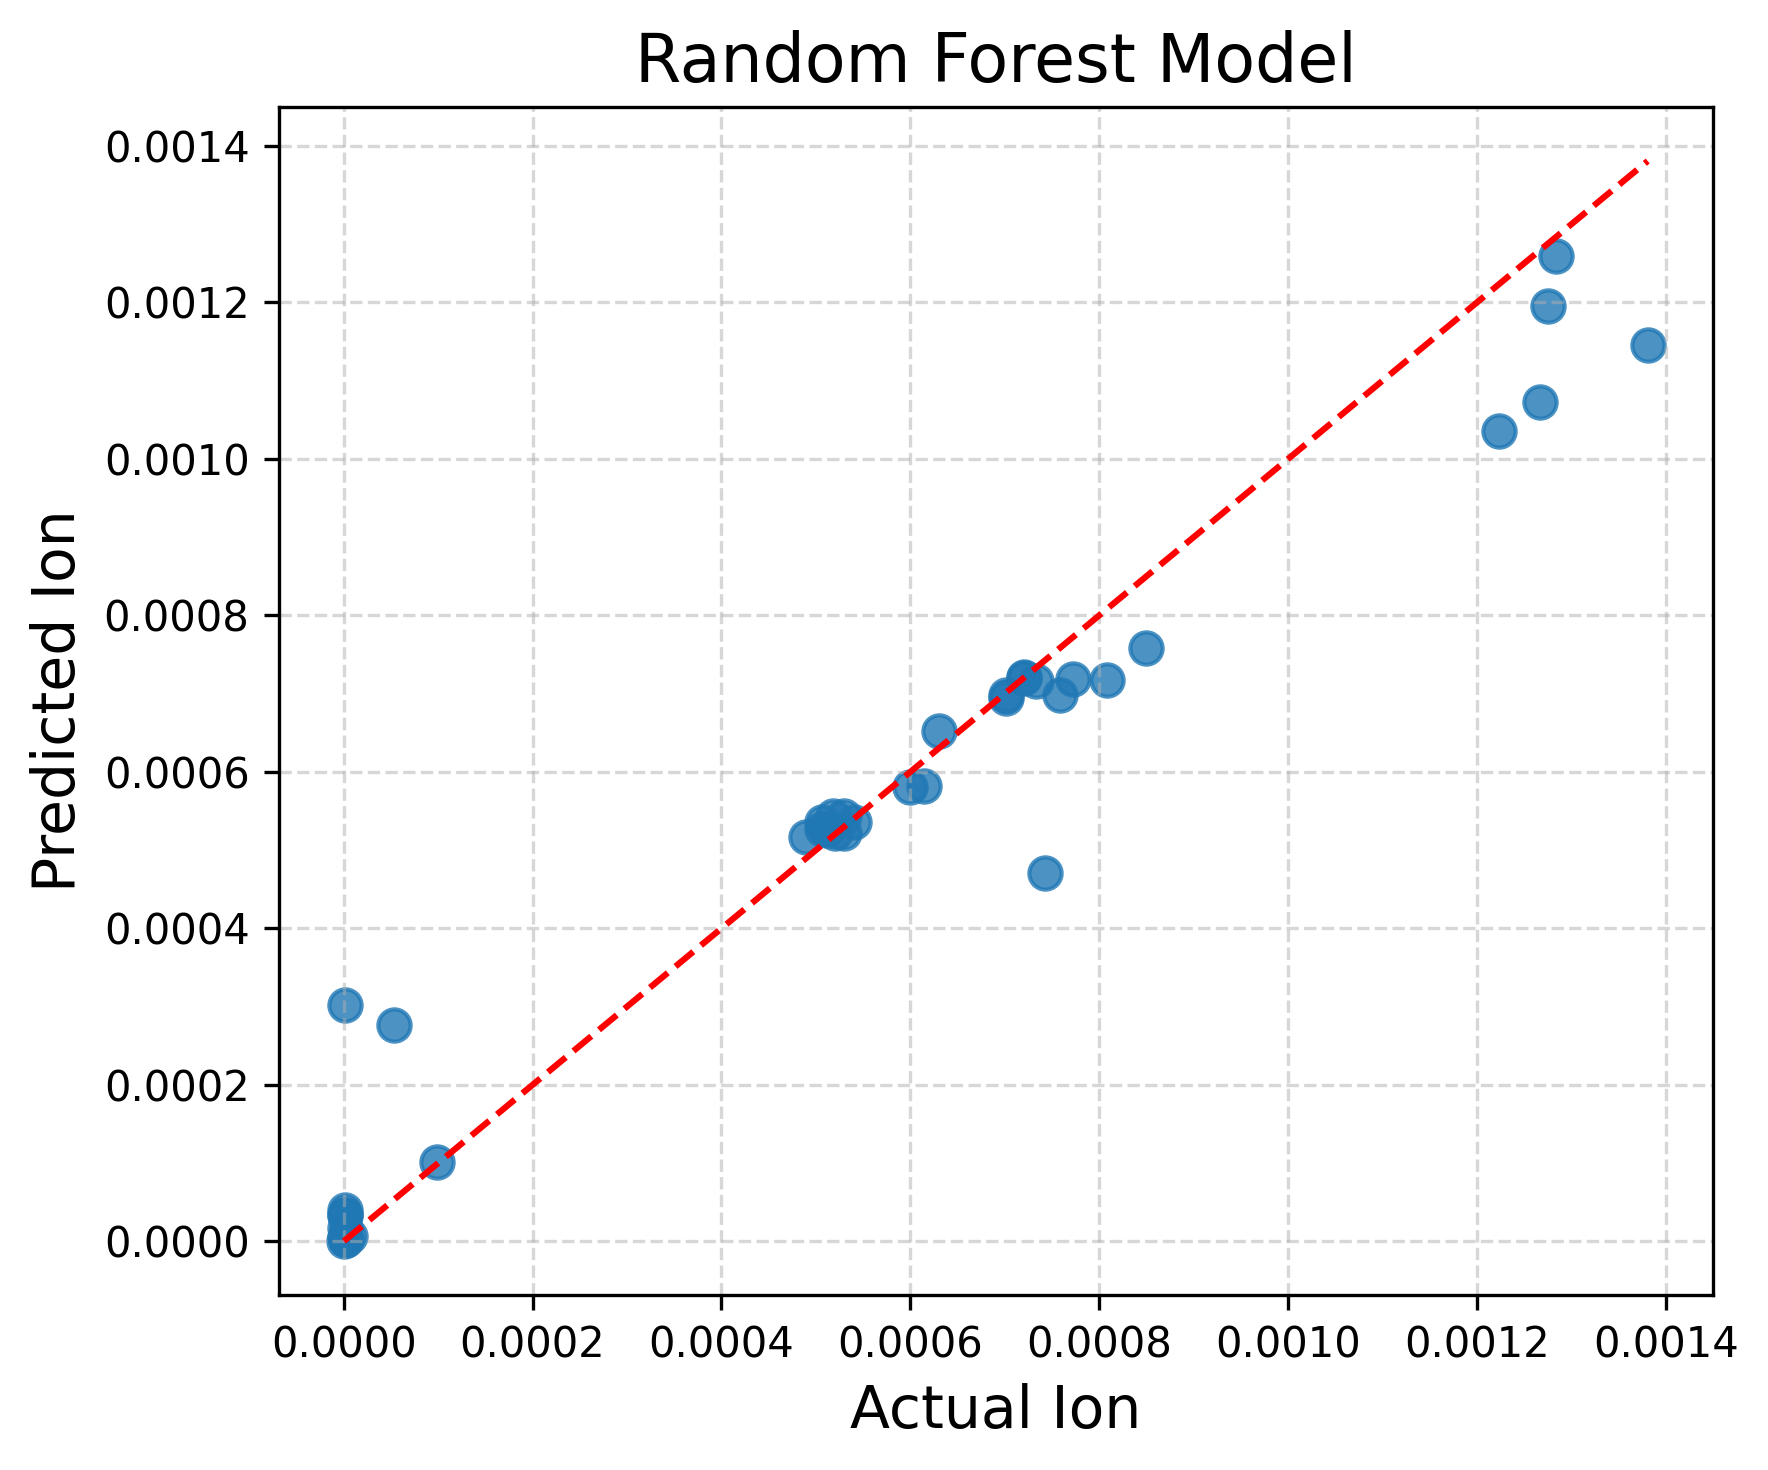

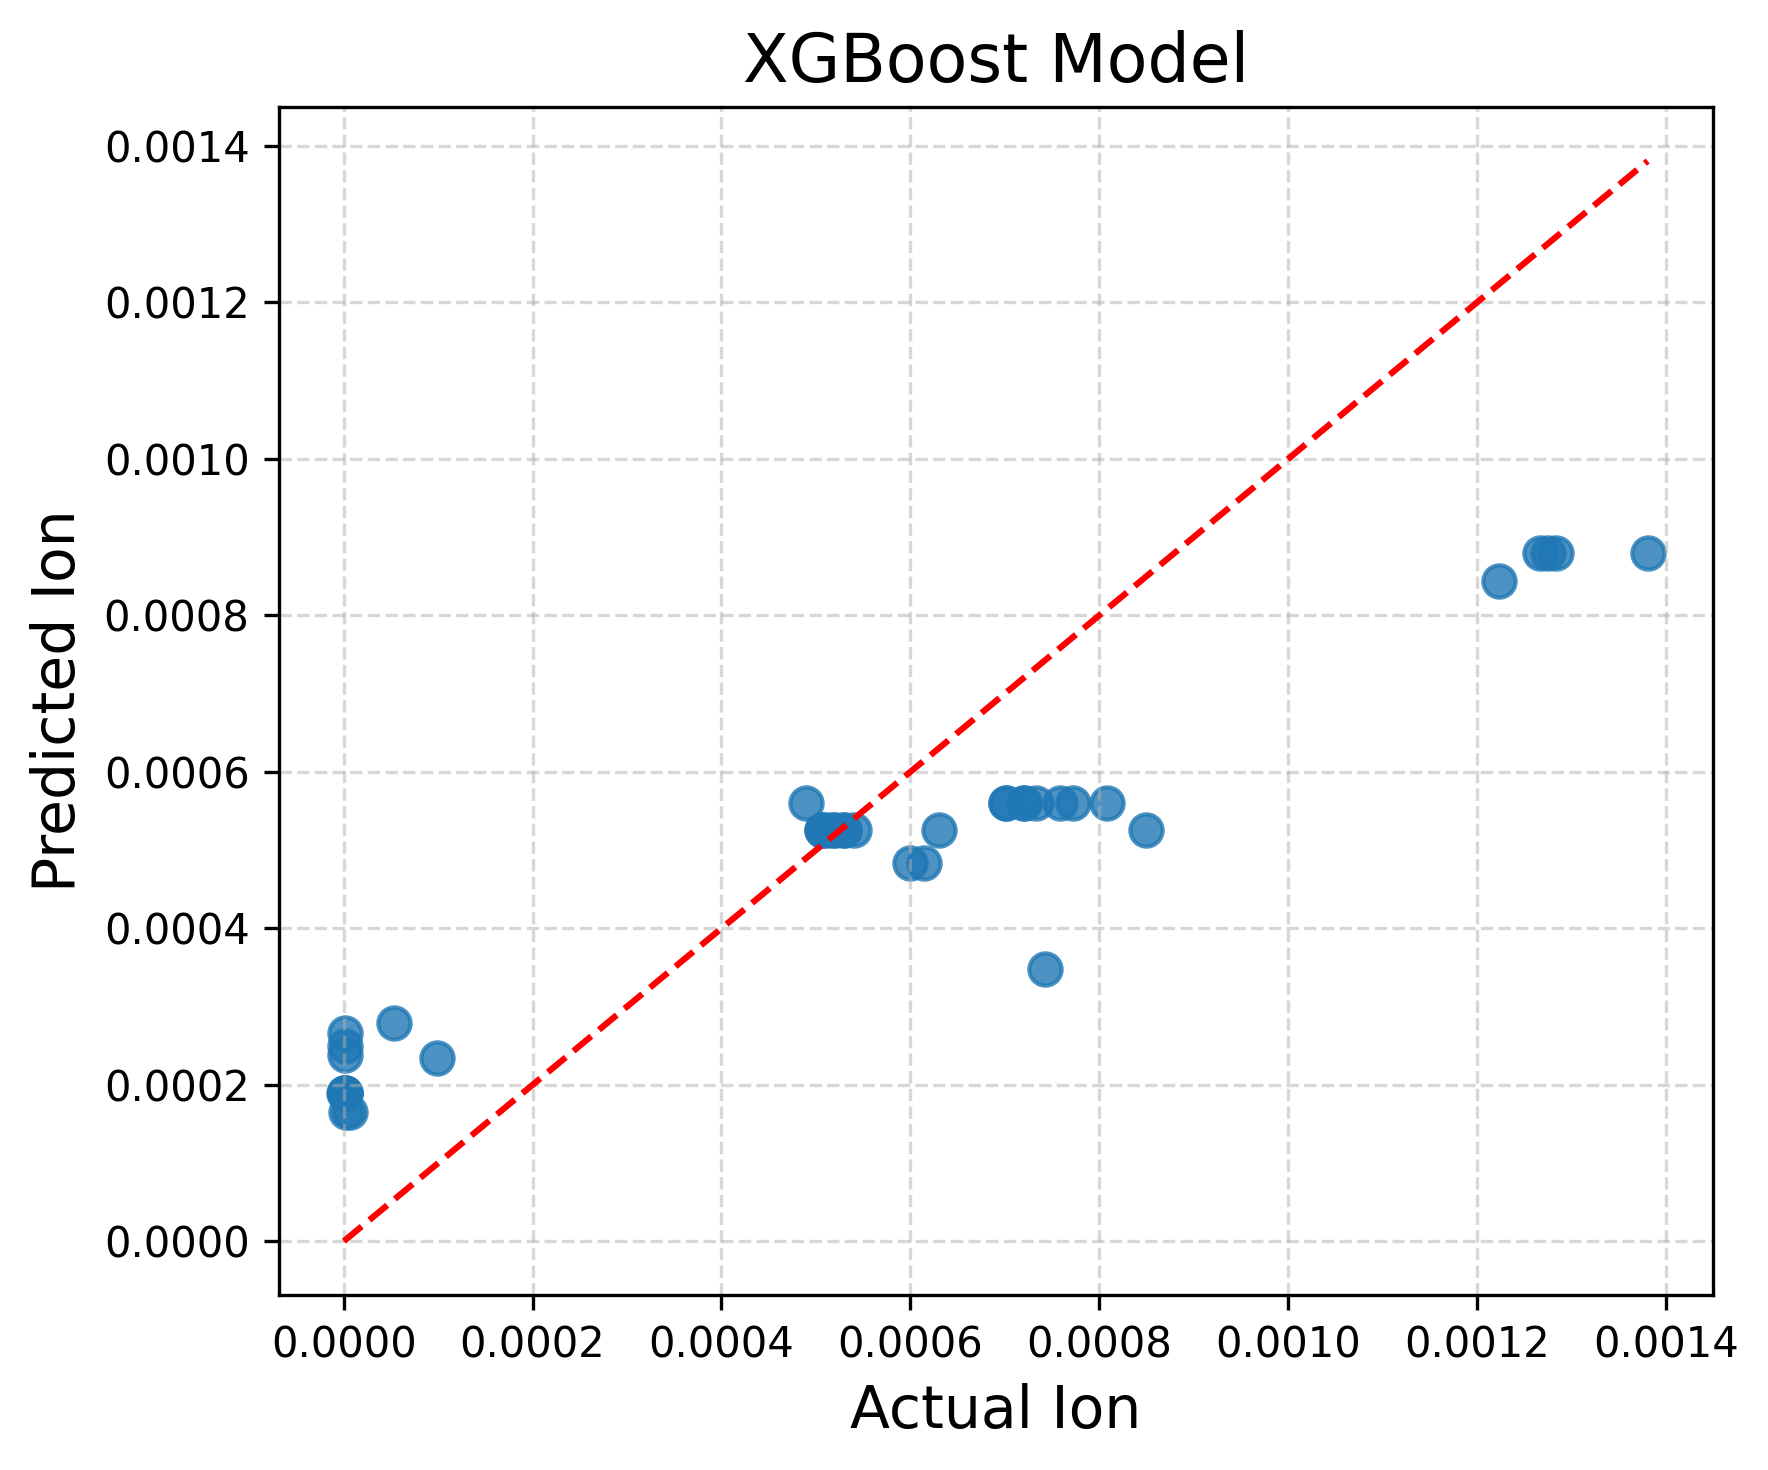

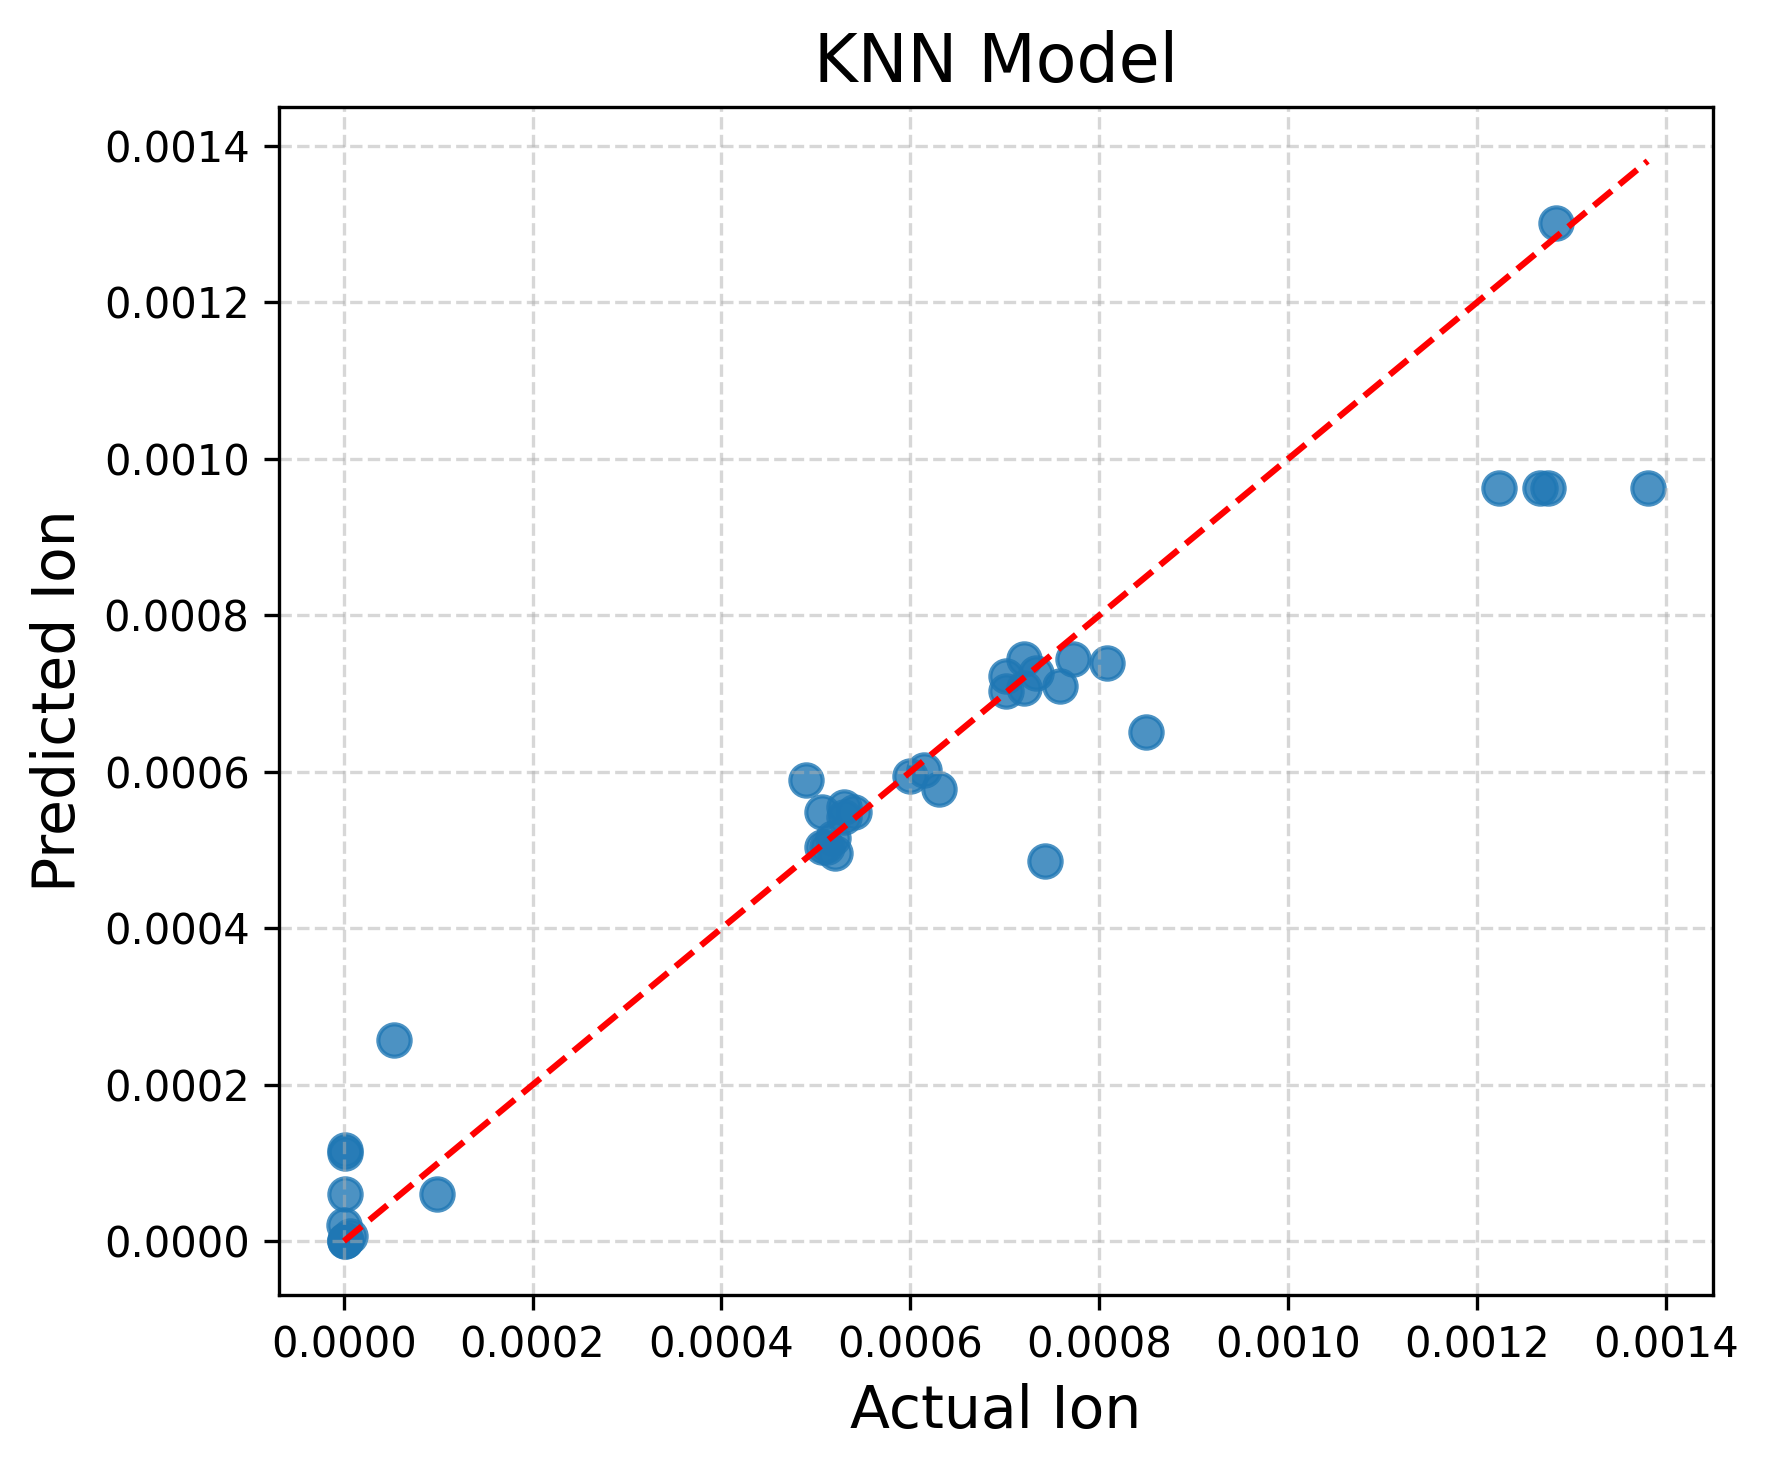

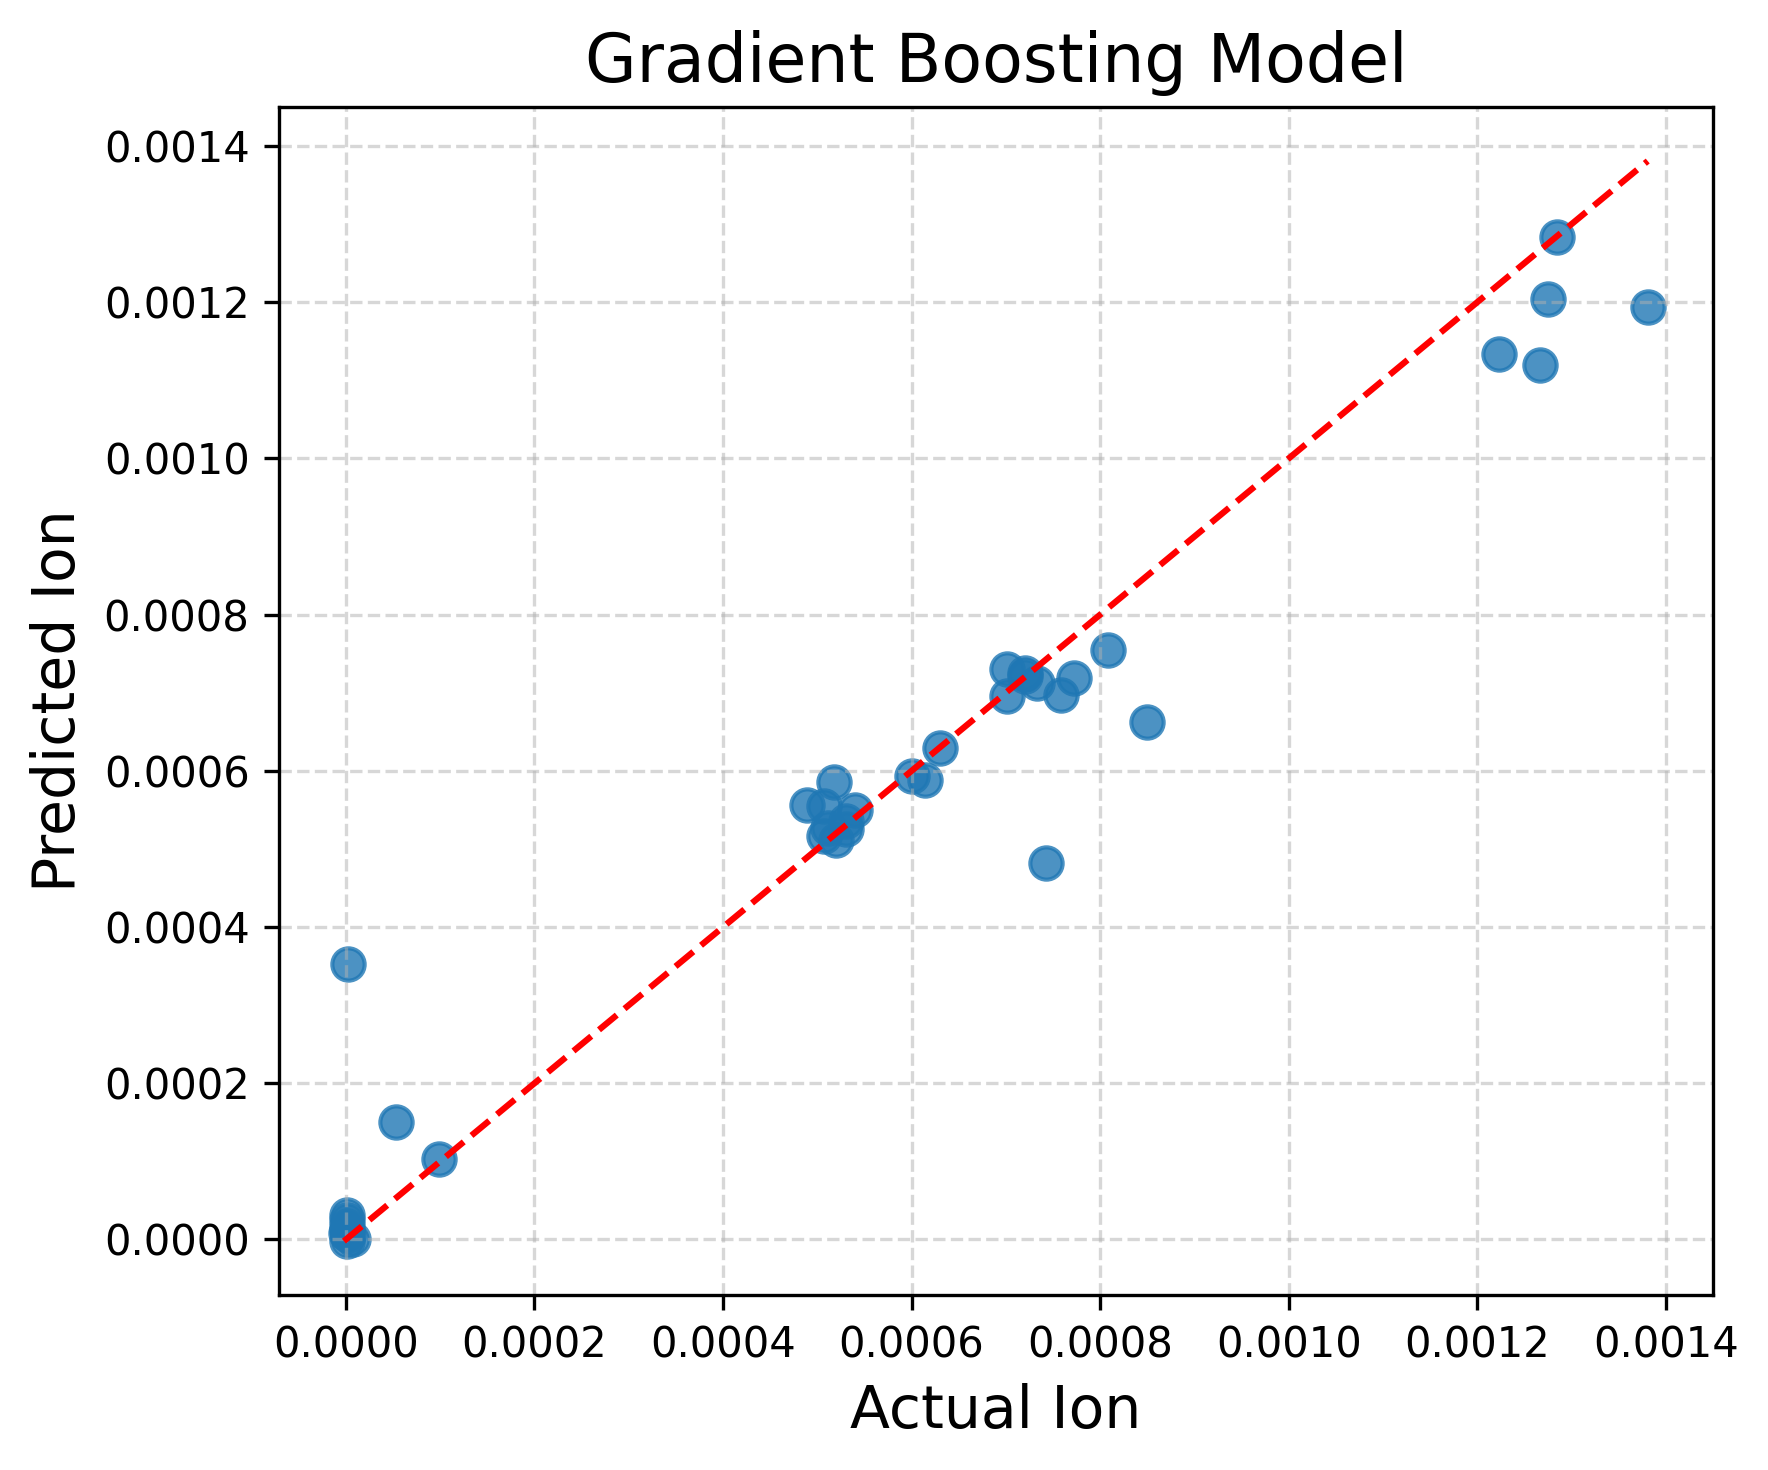


Model Comparison:
               Model        R2      RMSE
0  Linear Regression  0.671235  0.000234
1      Random Forest  0.939763  0.000100
2            XGBoost  0.700837  0.000223
3                KNN  0.899185  0.000130
4  Gradient Boosting  0.947552  0.000093

Classification Accuracy: 0.8947368421052632


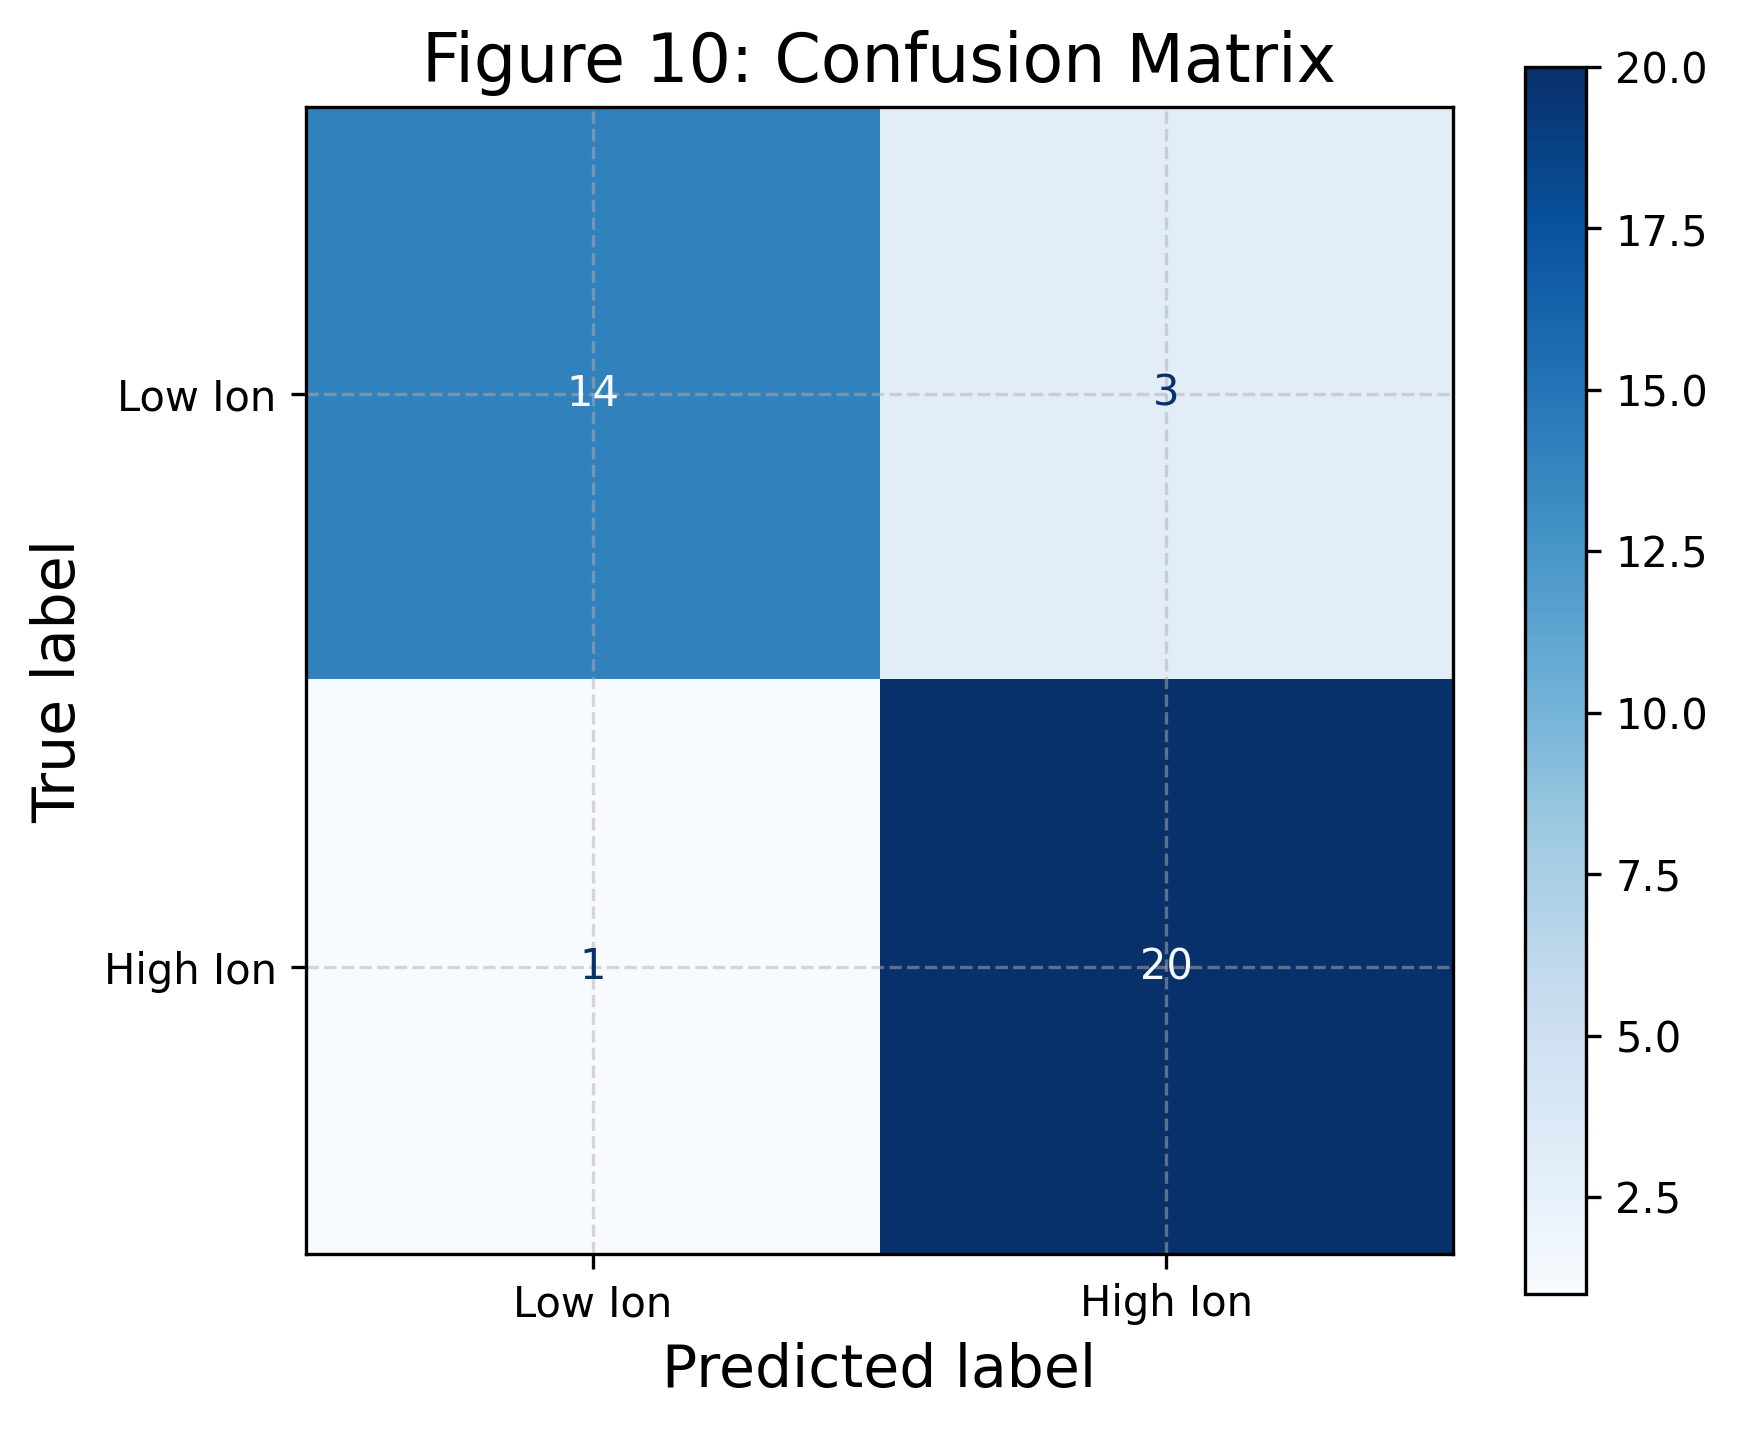

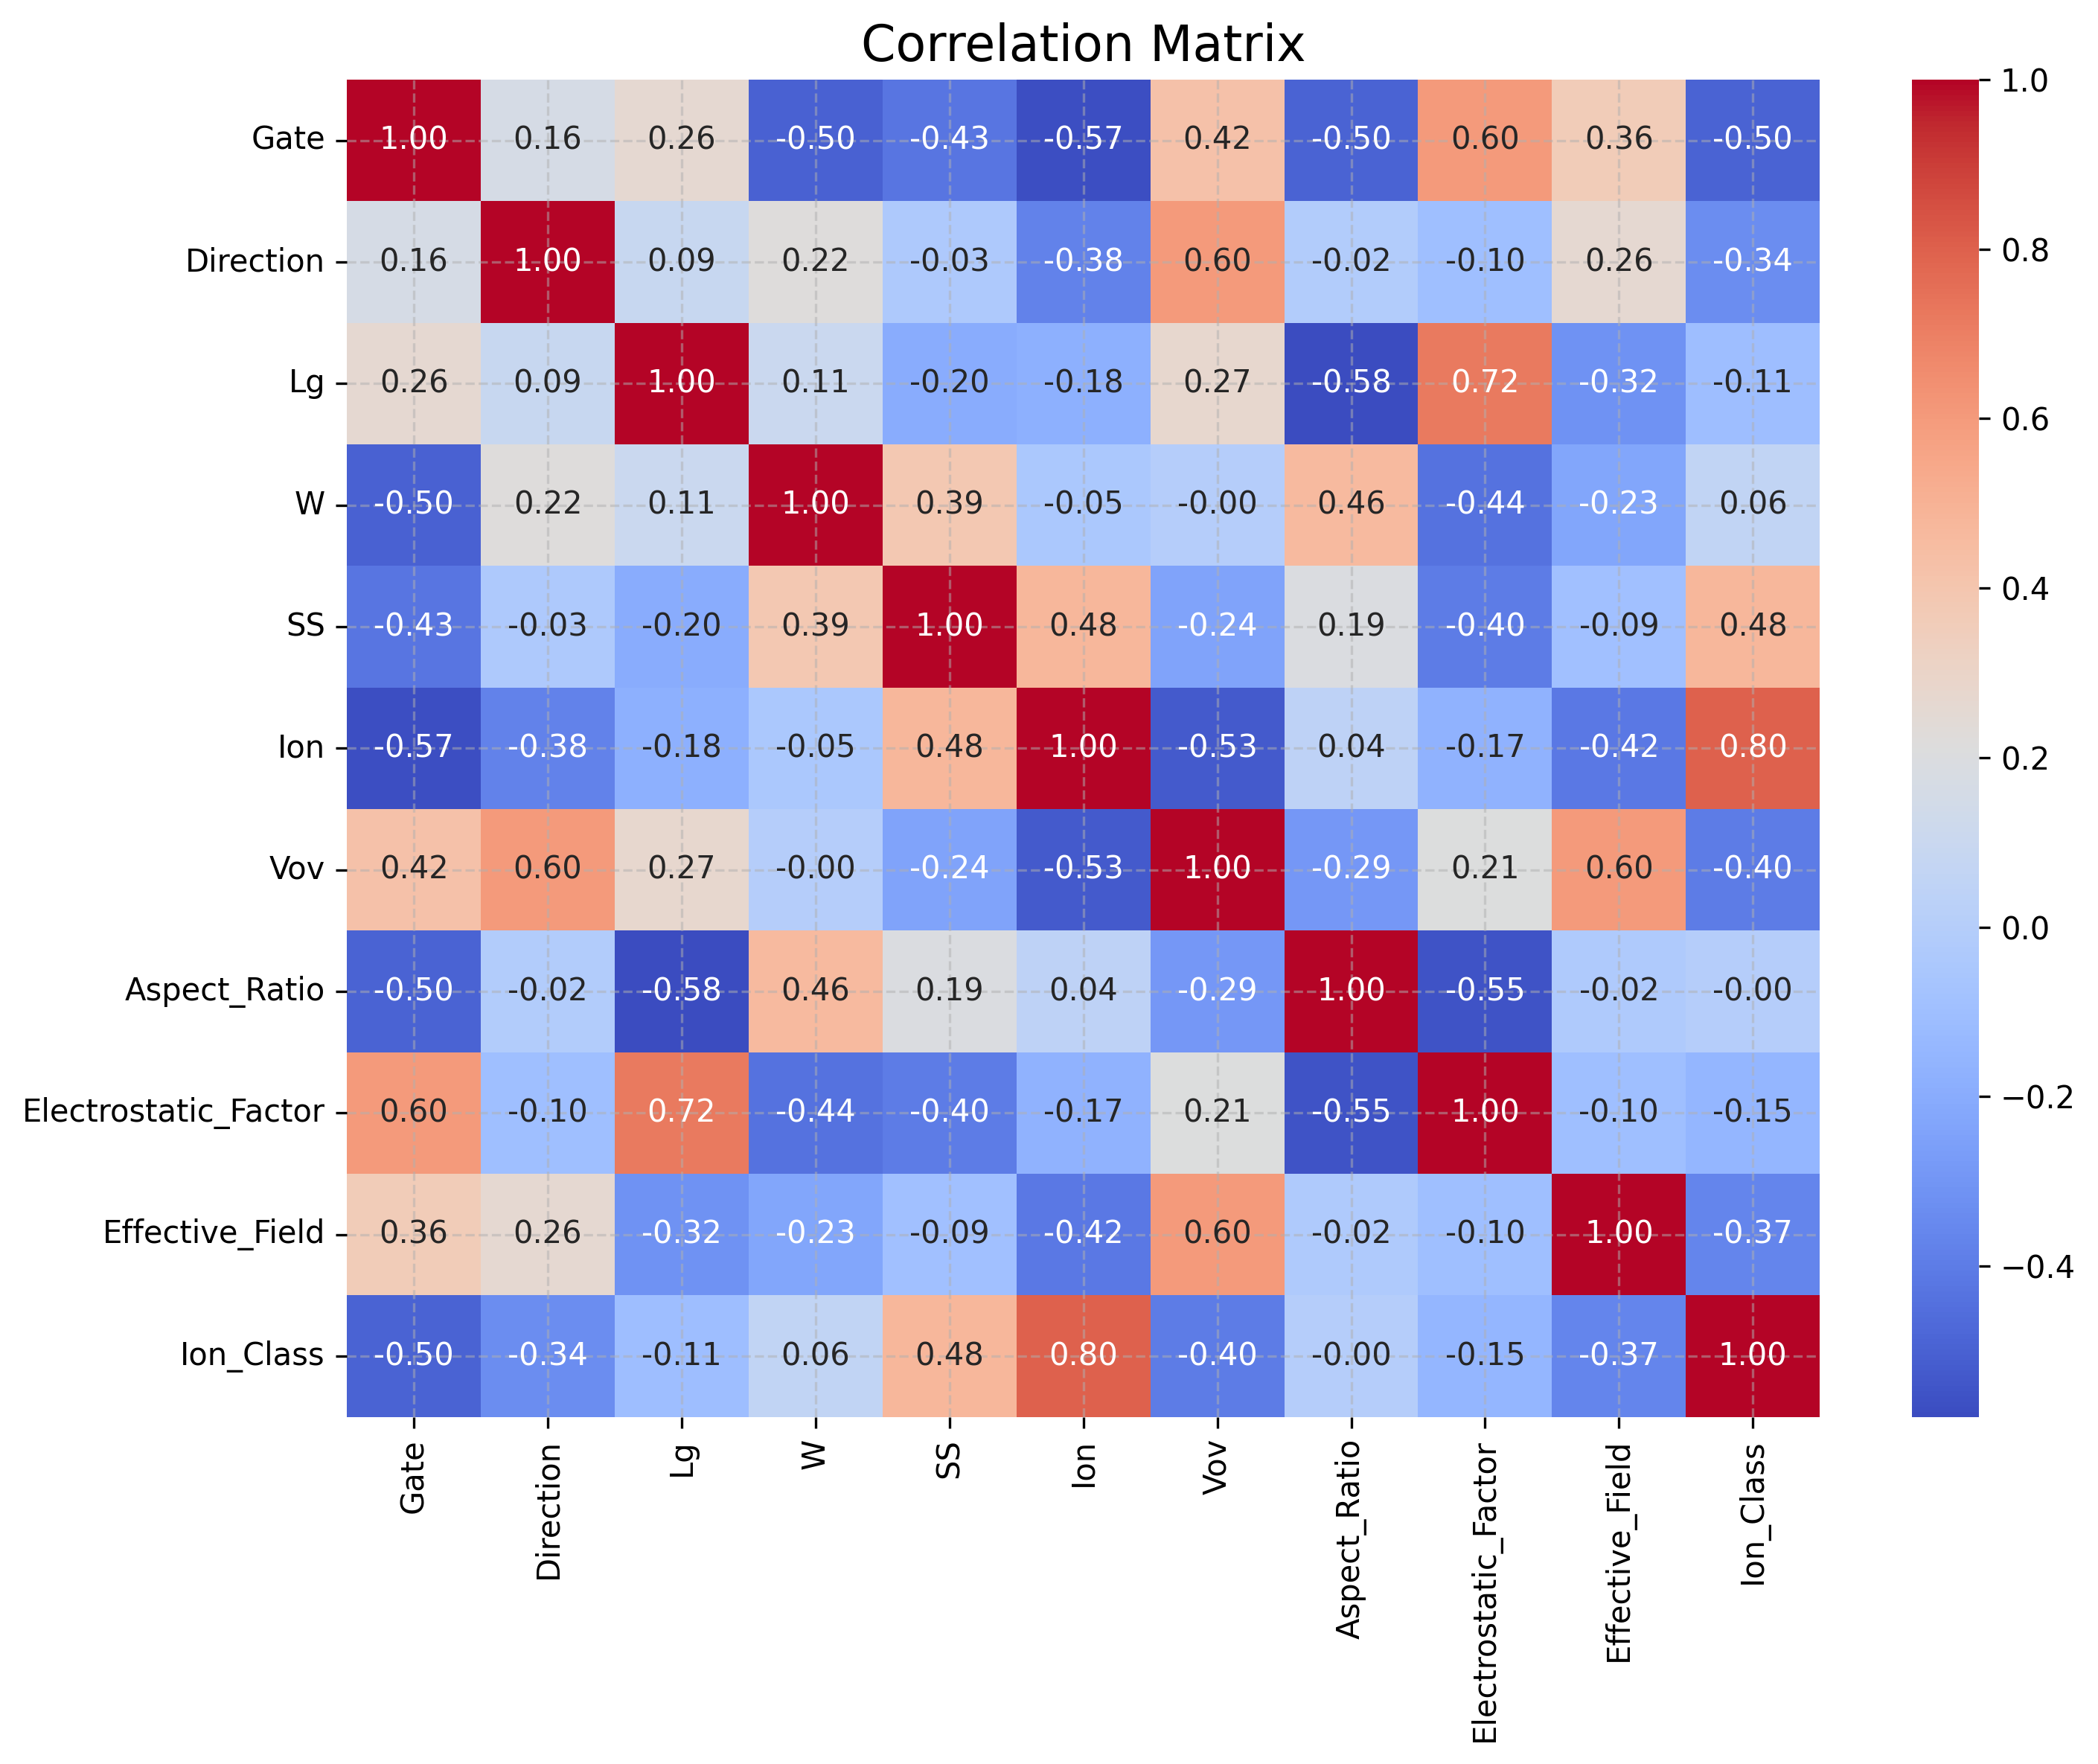

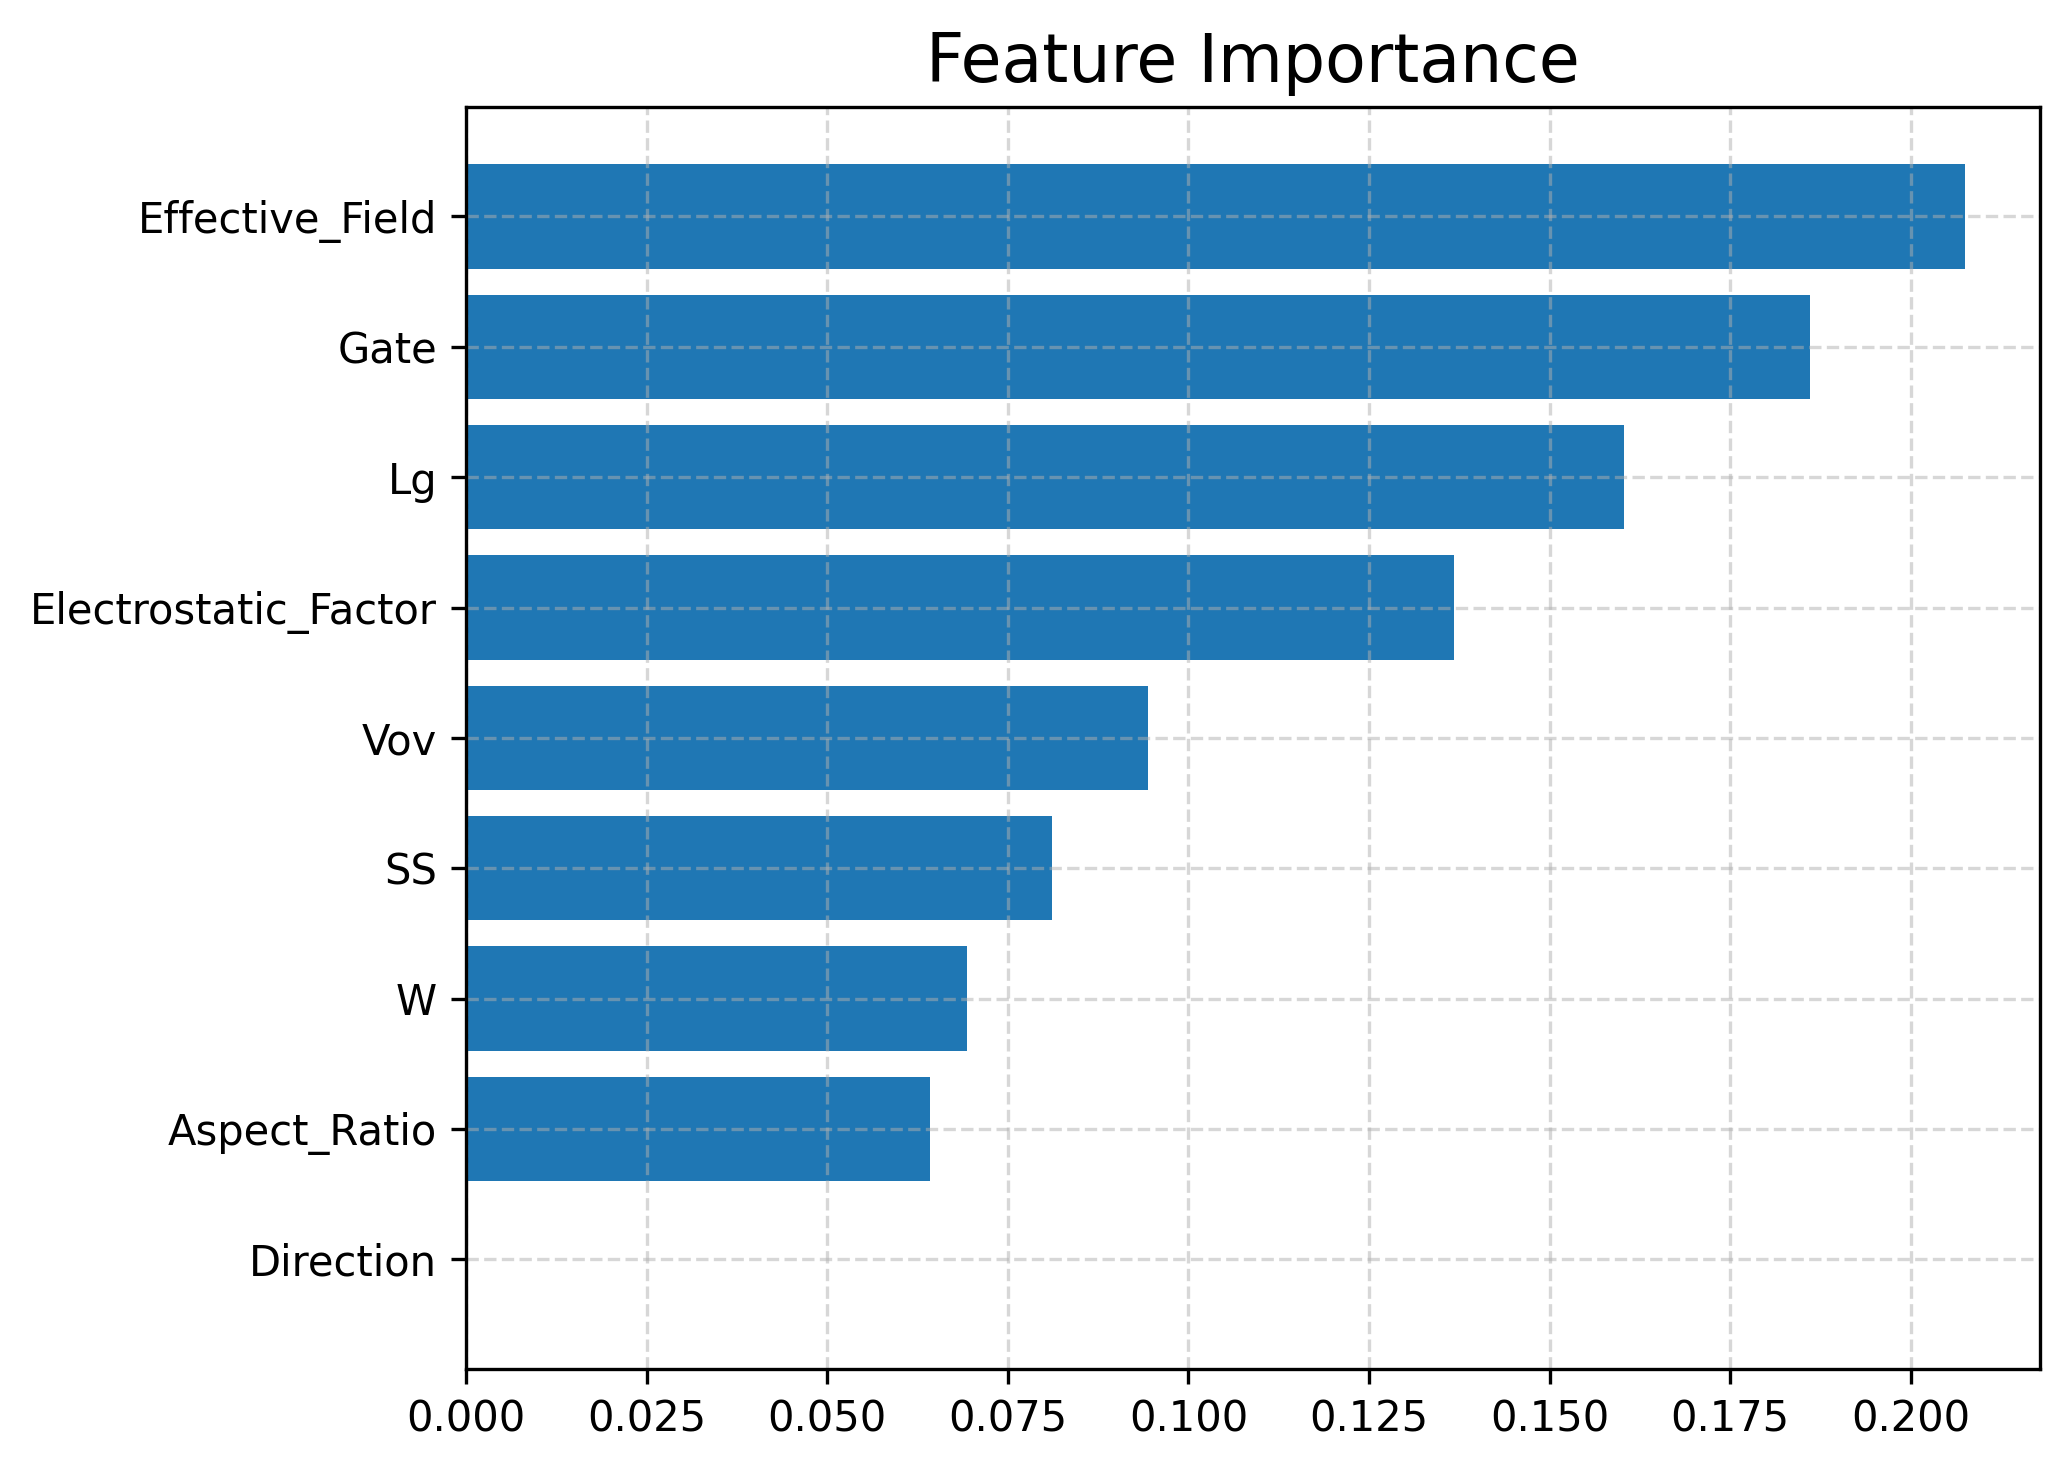

/tmp/ipykernel_21967/1961598495.py:303: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


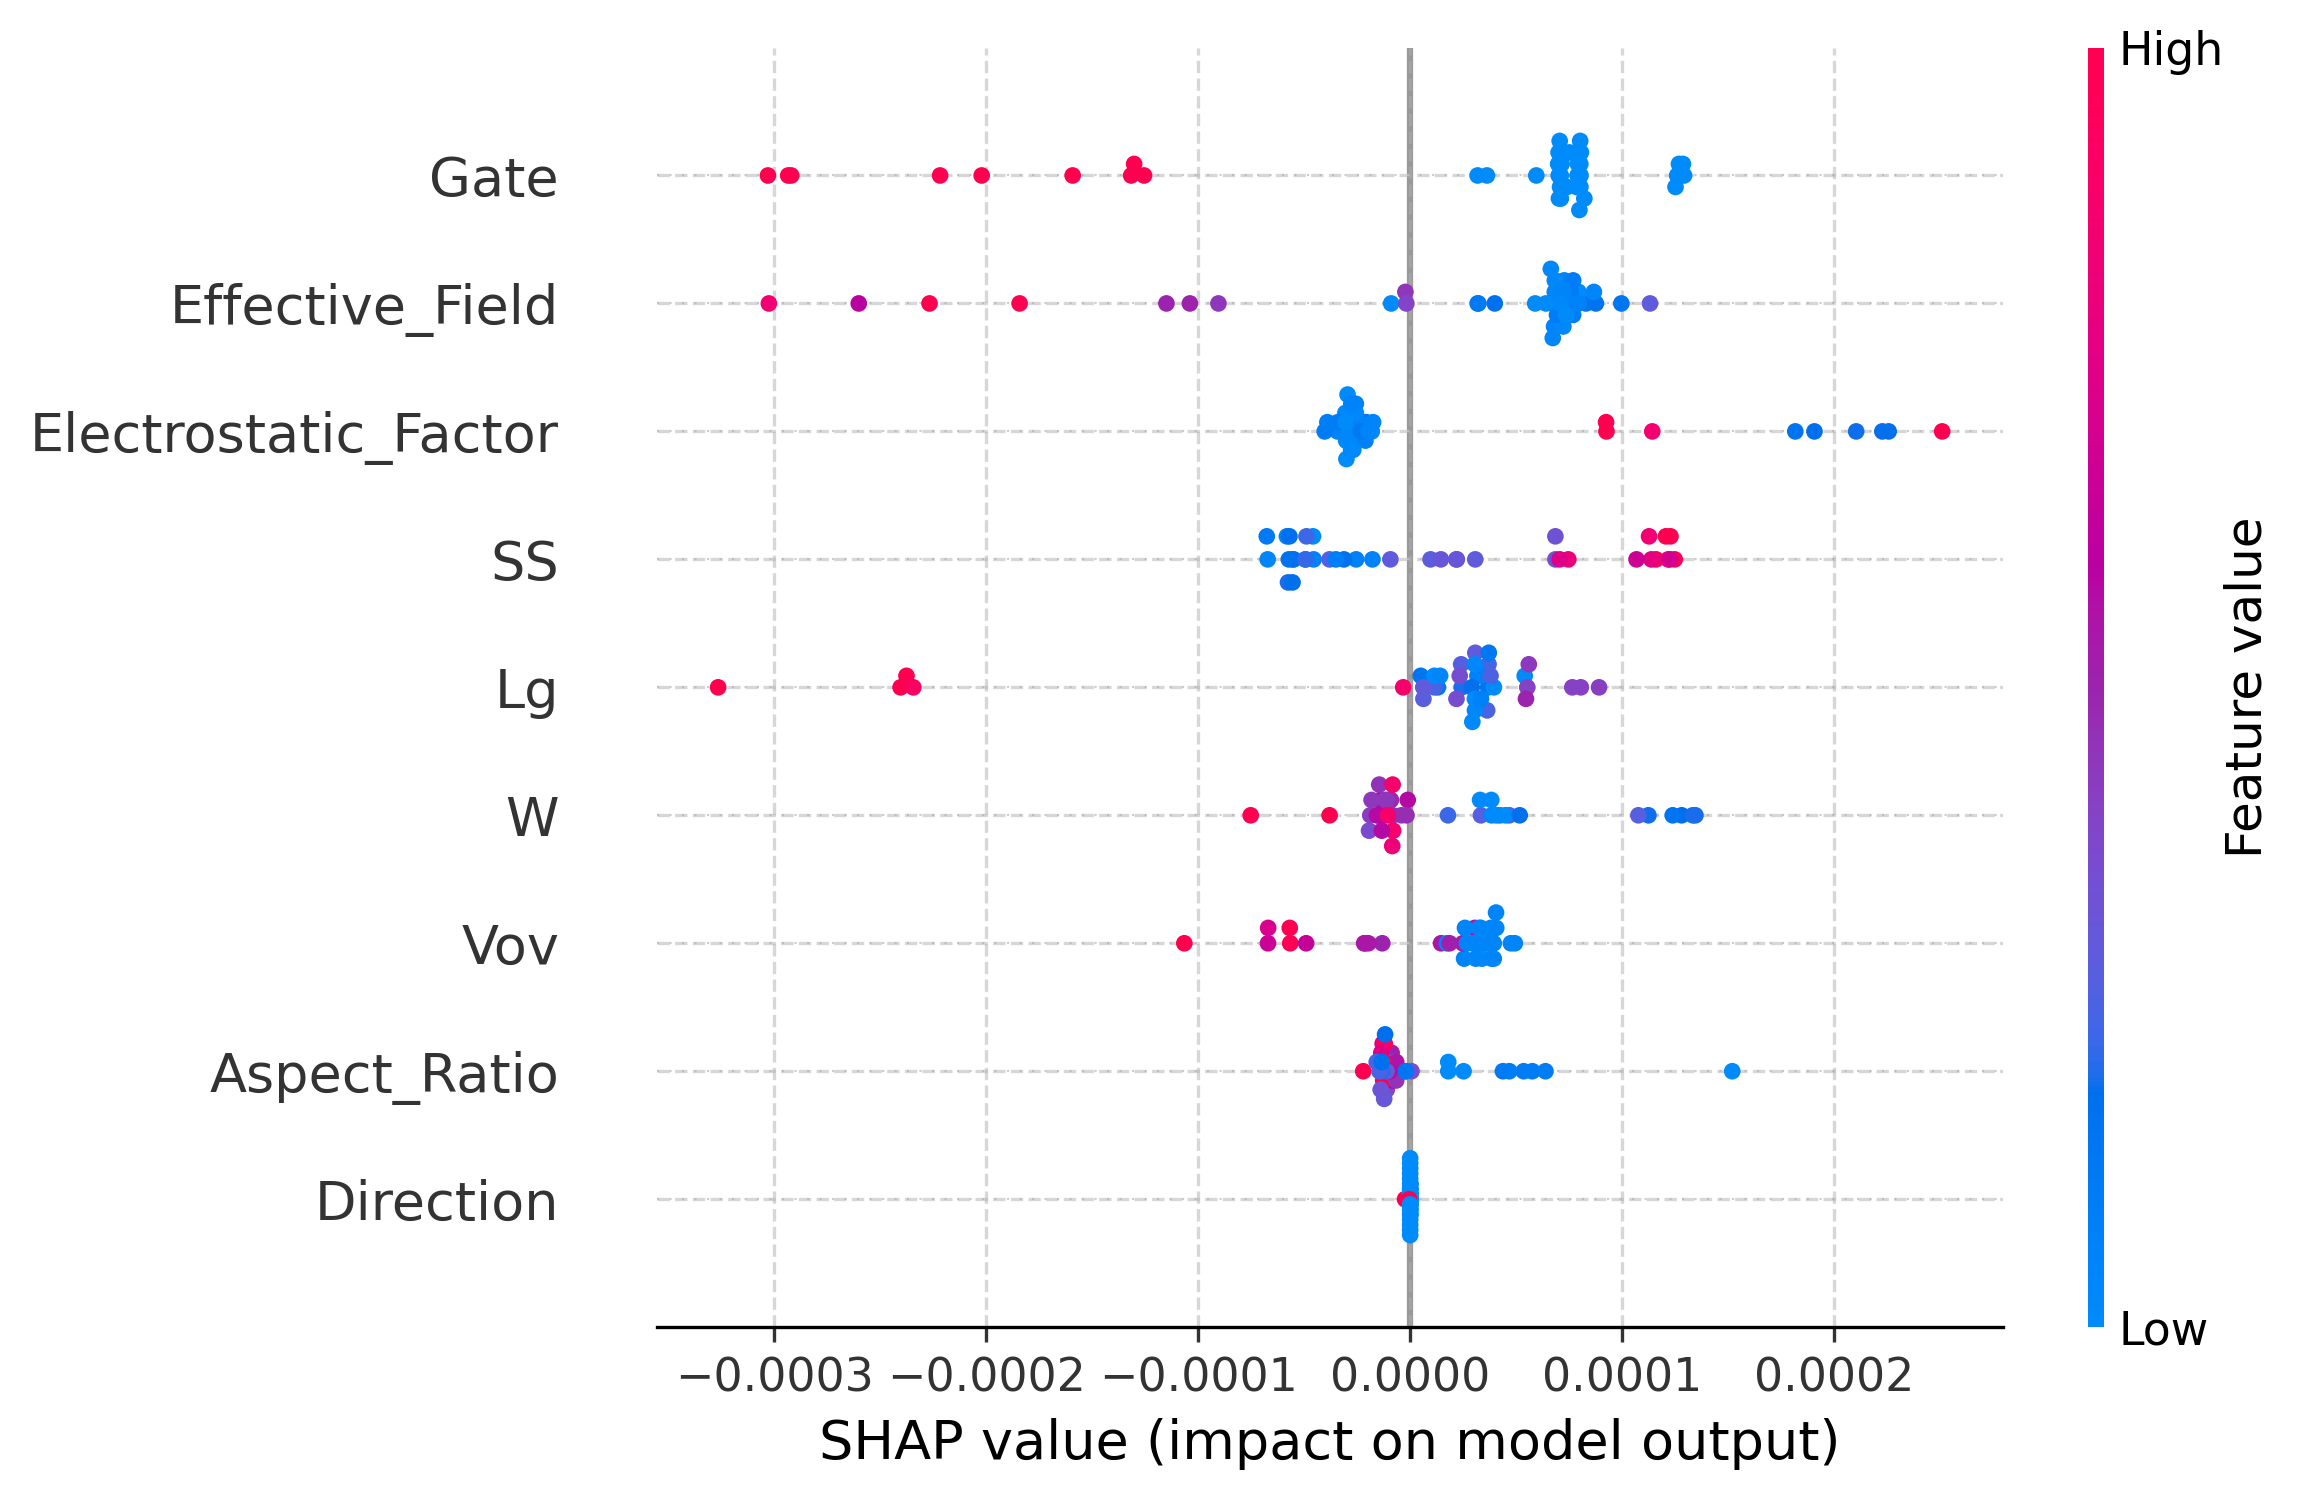

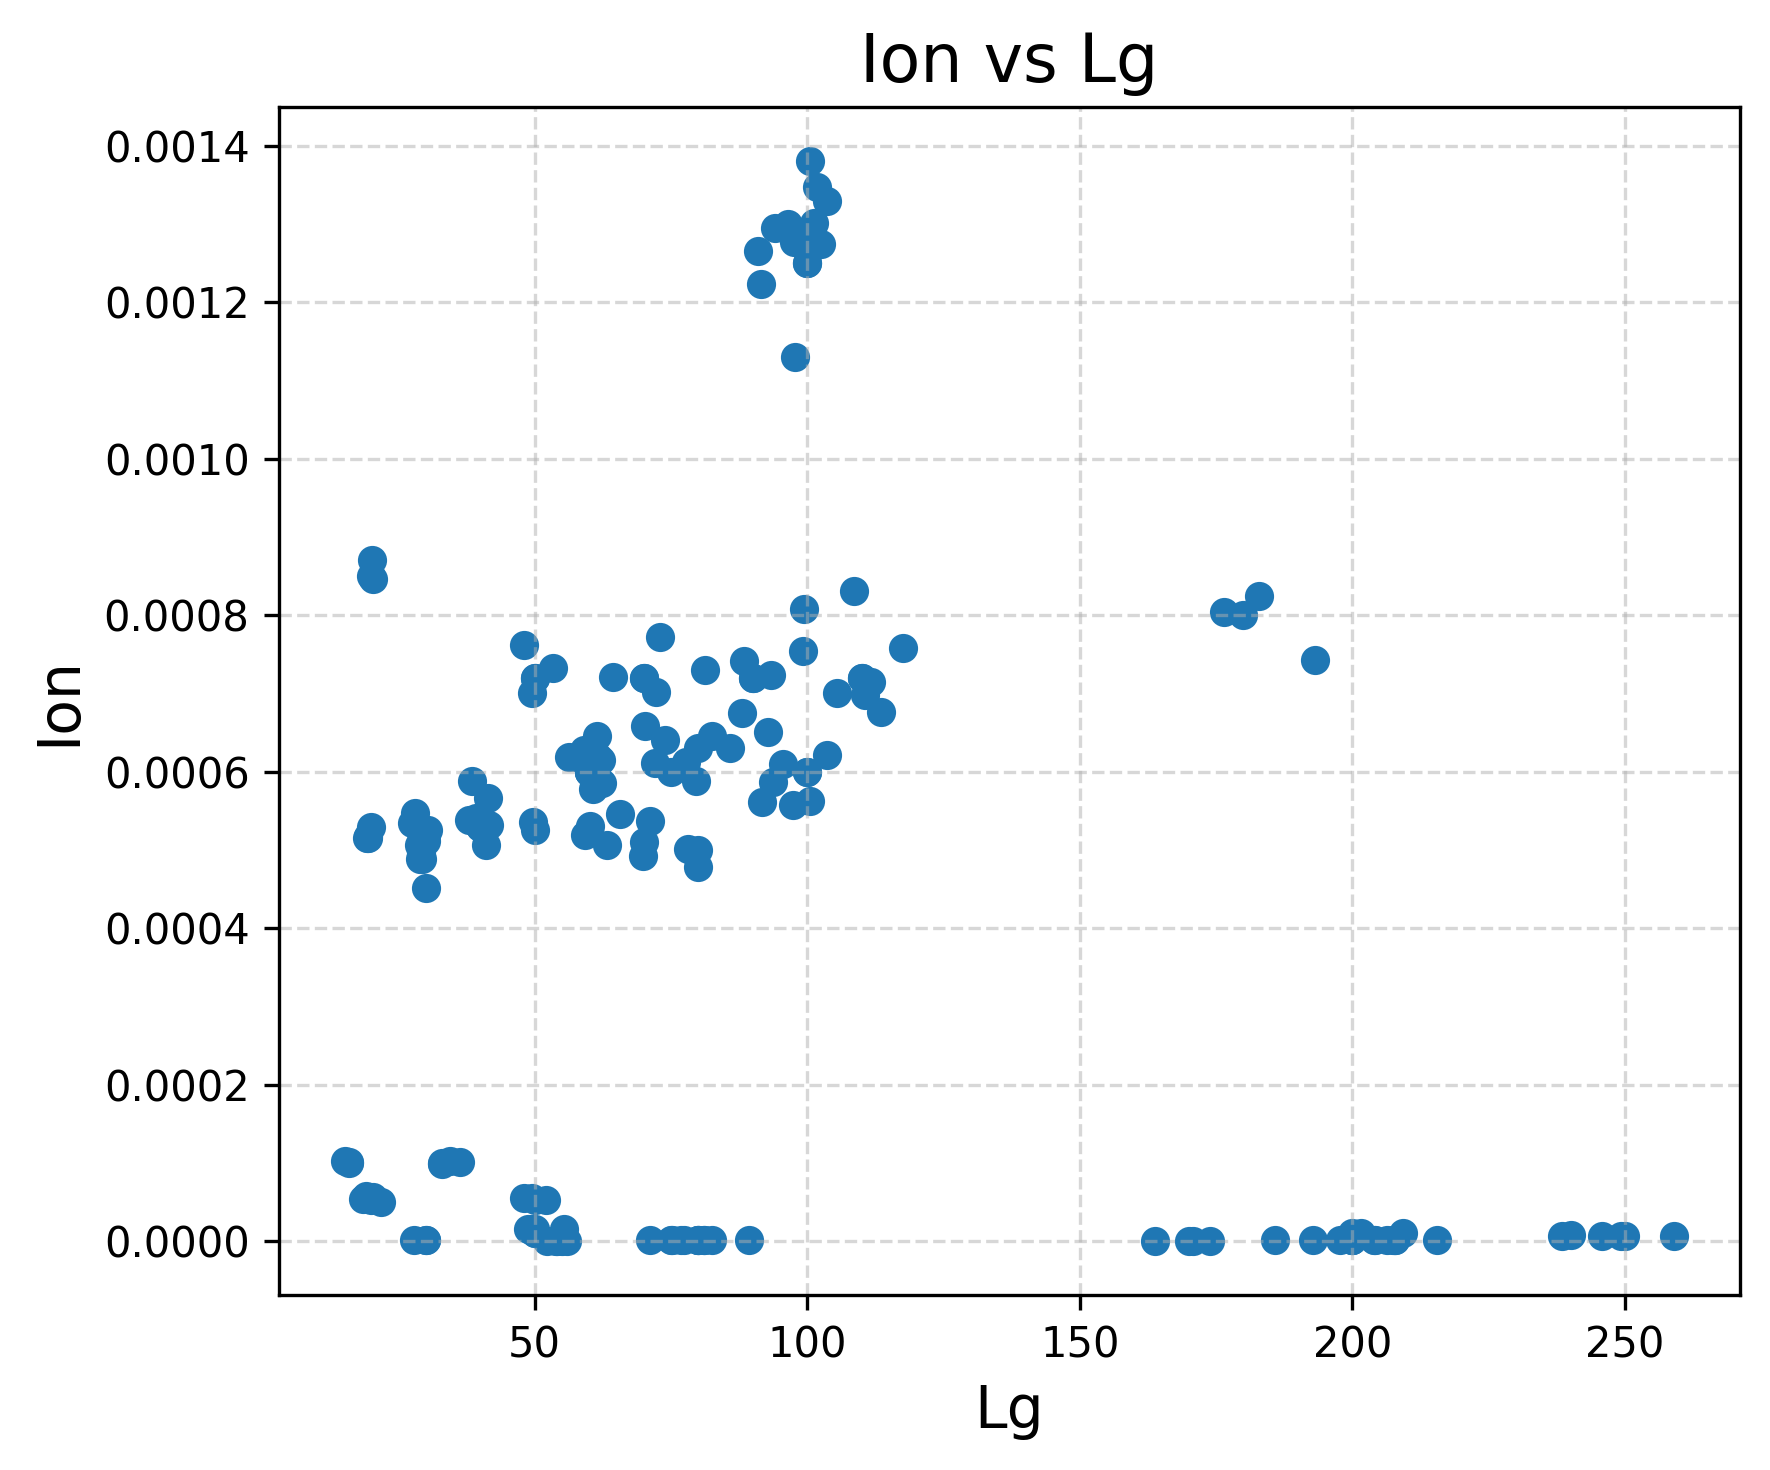

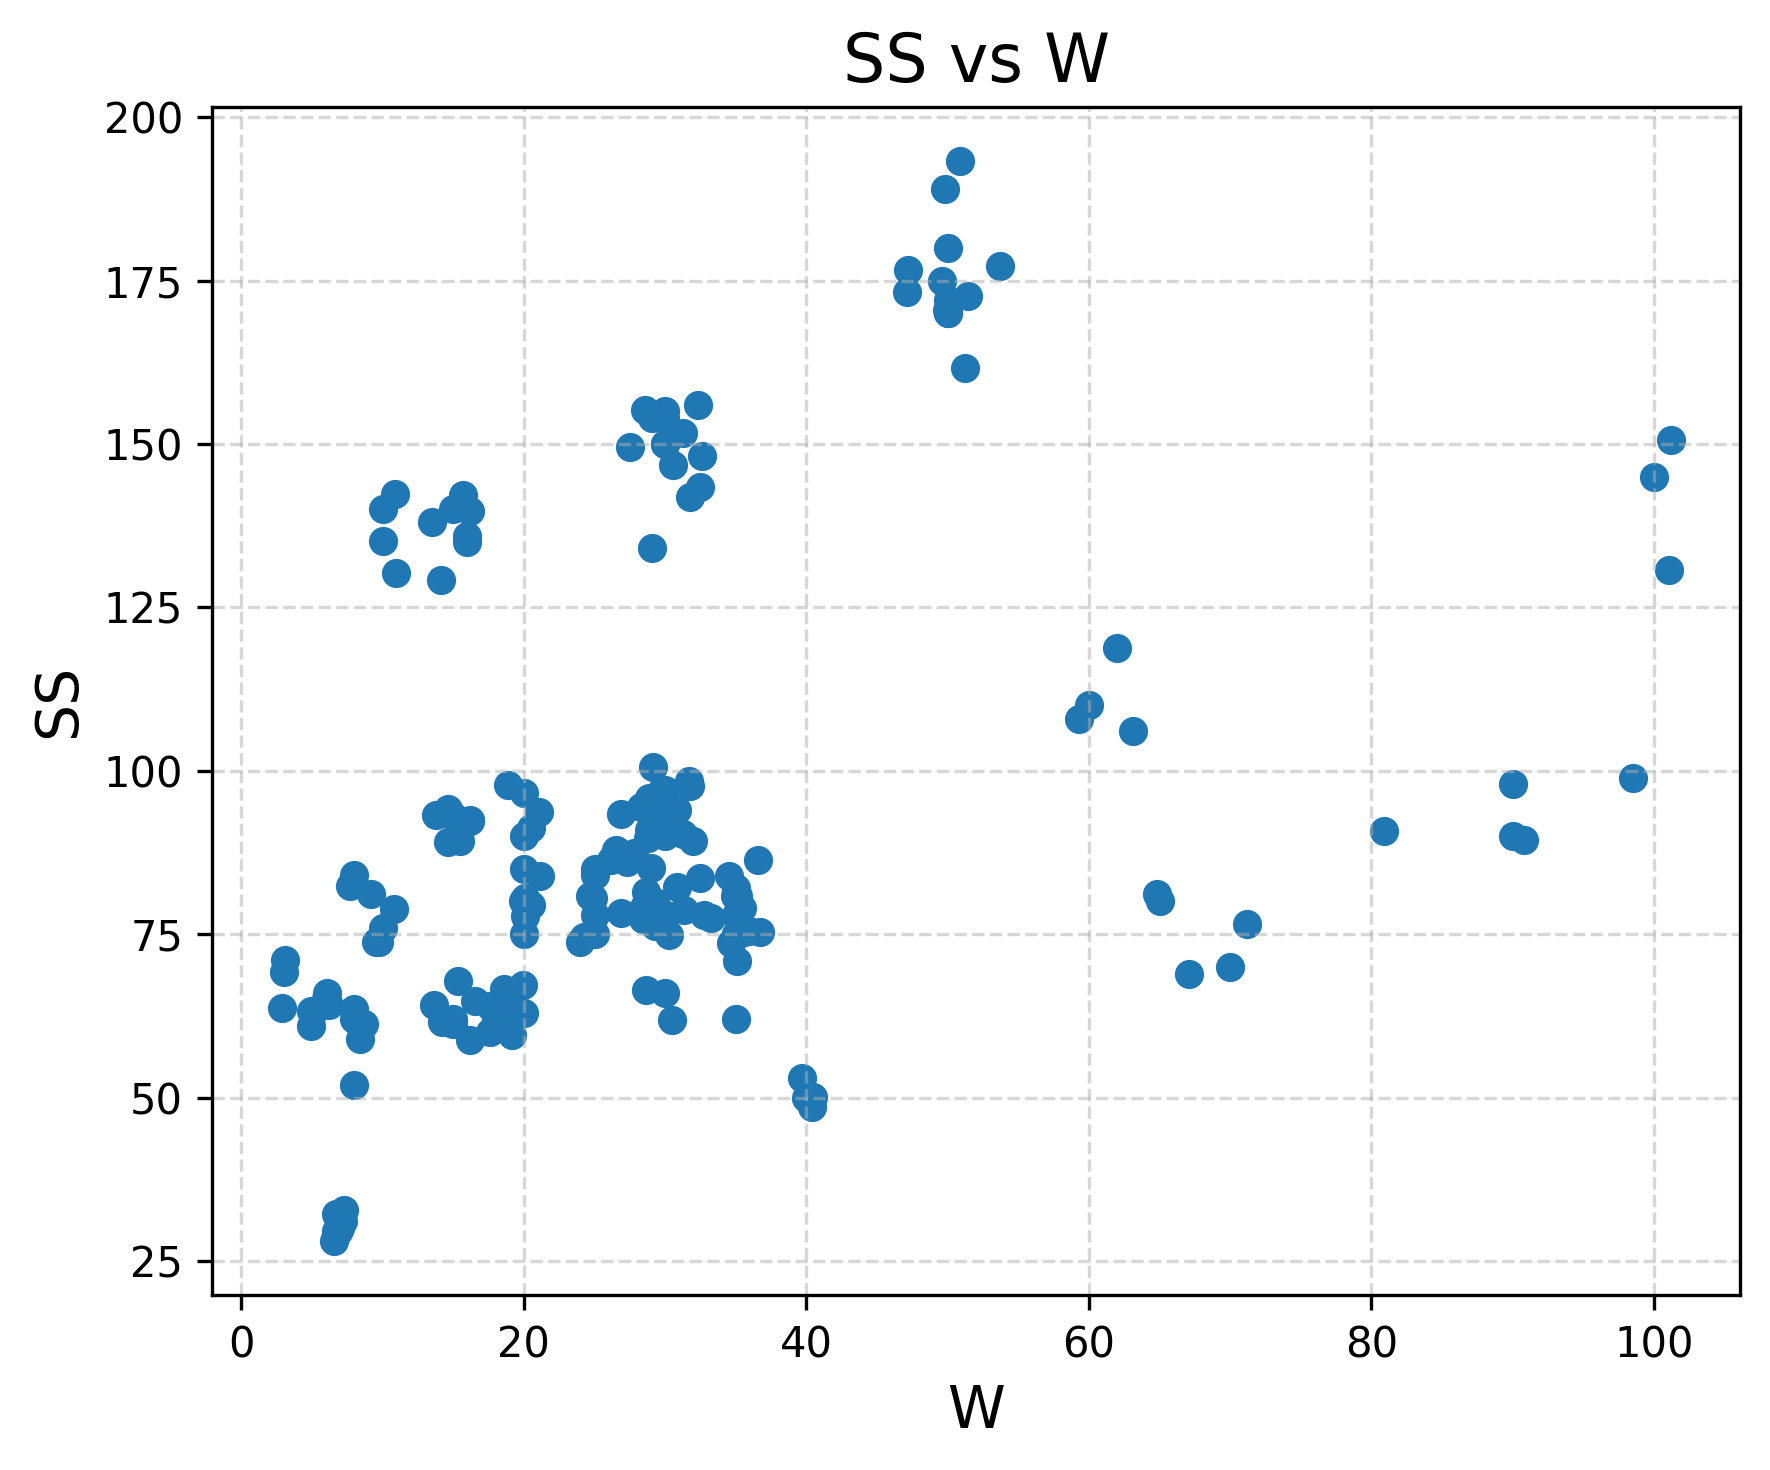

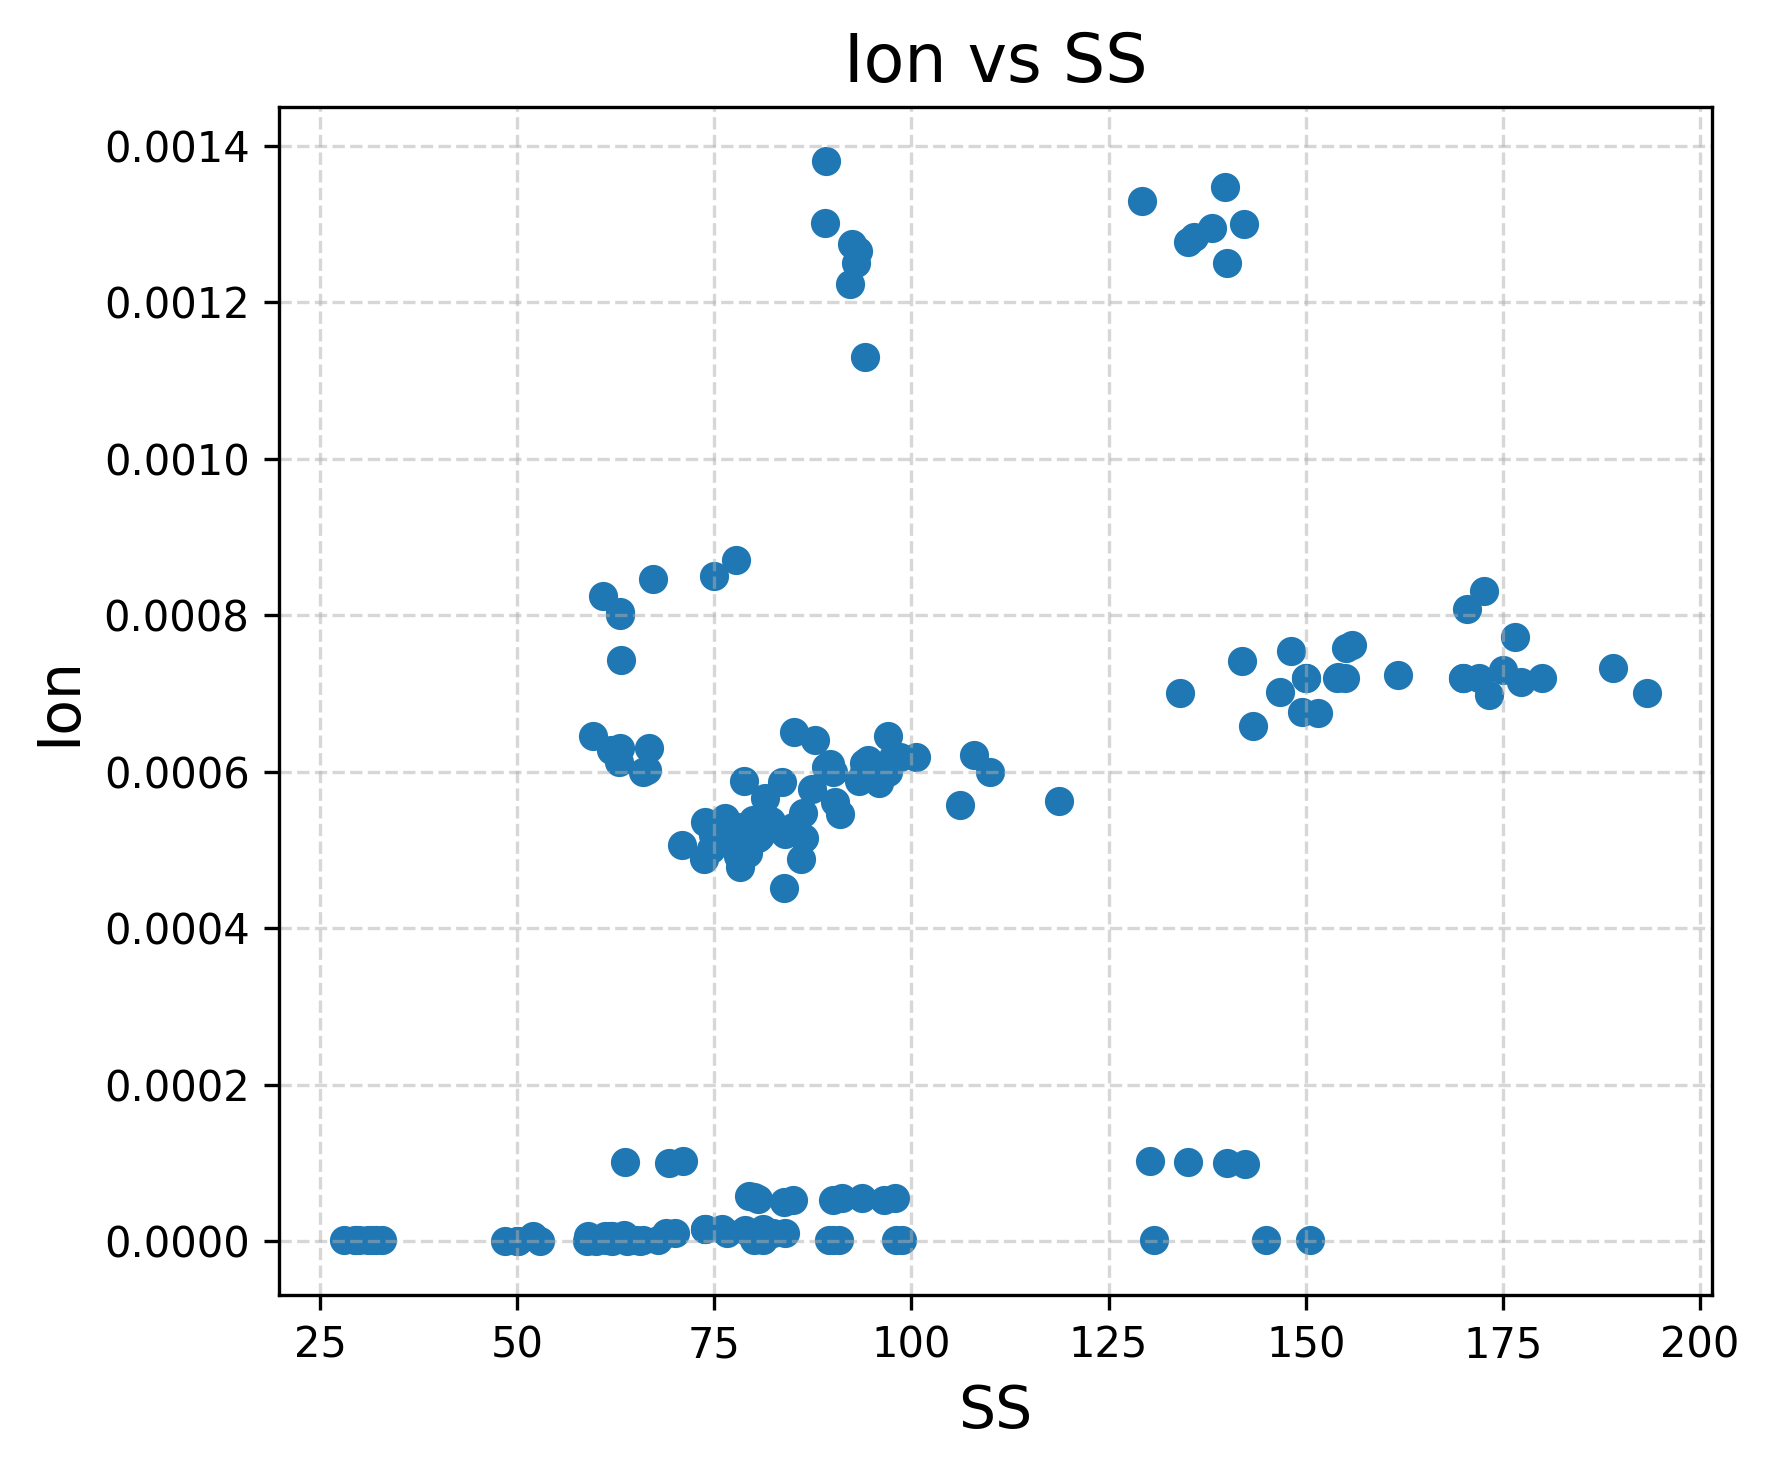

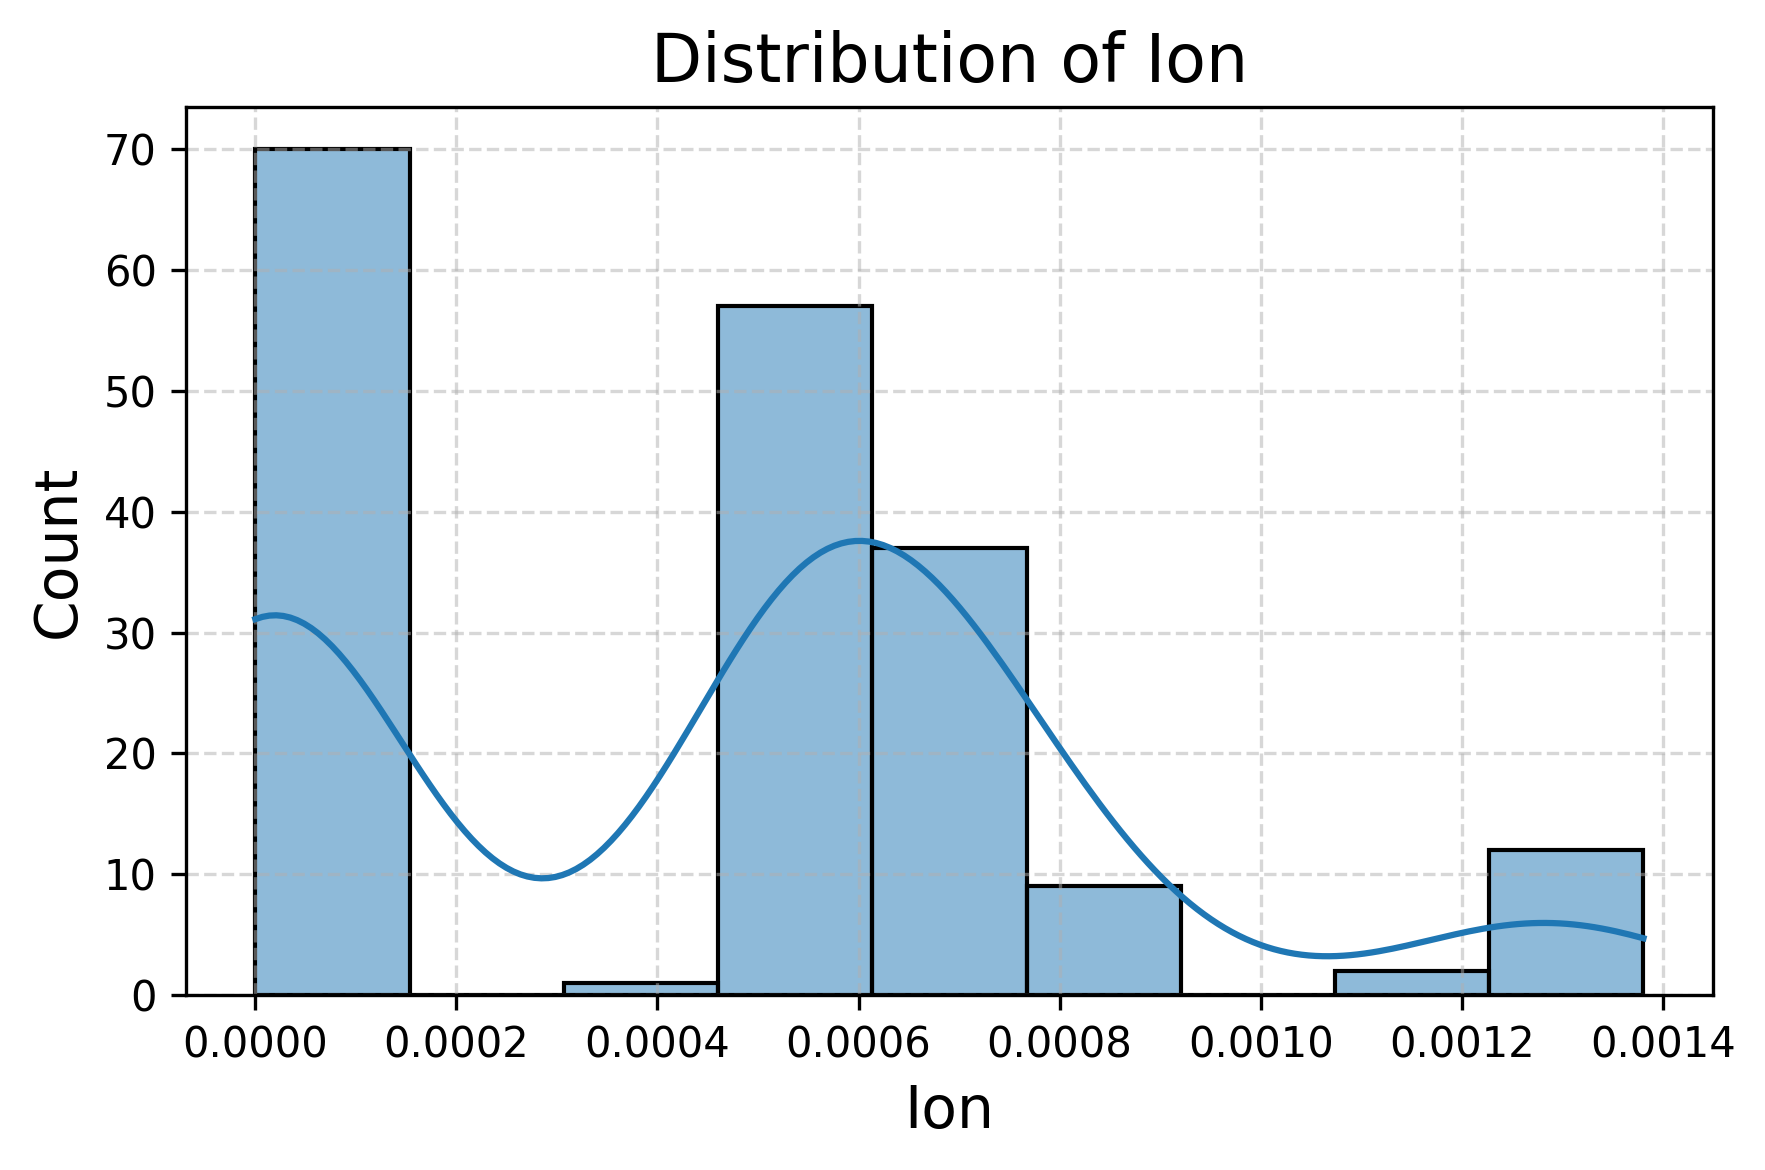

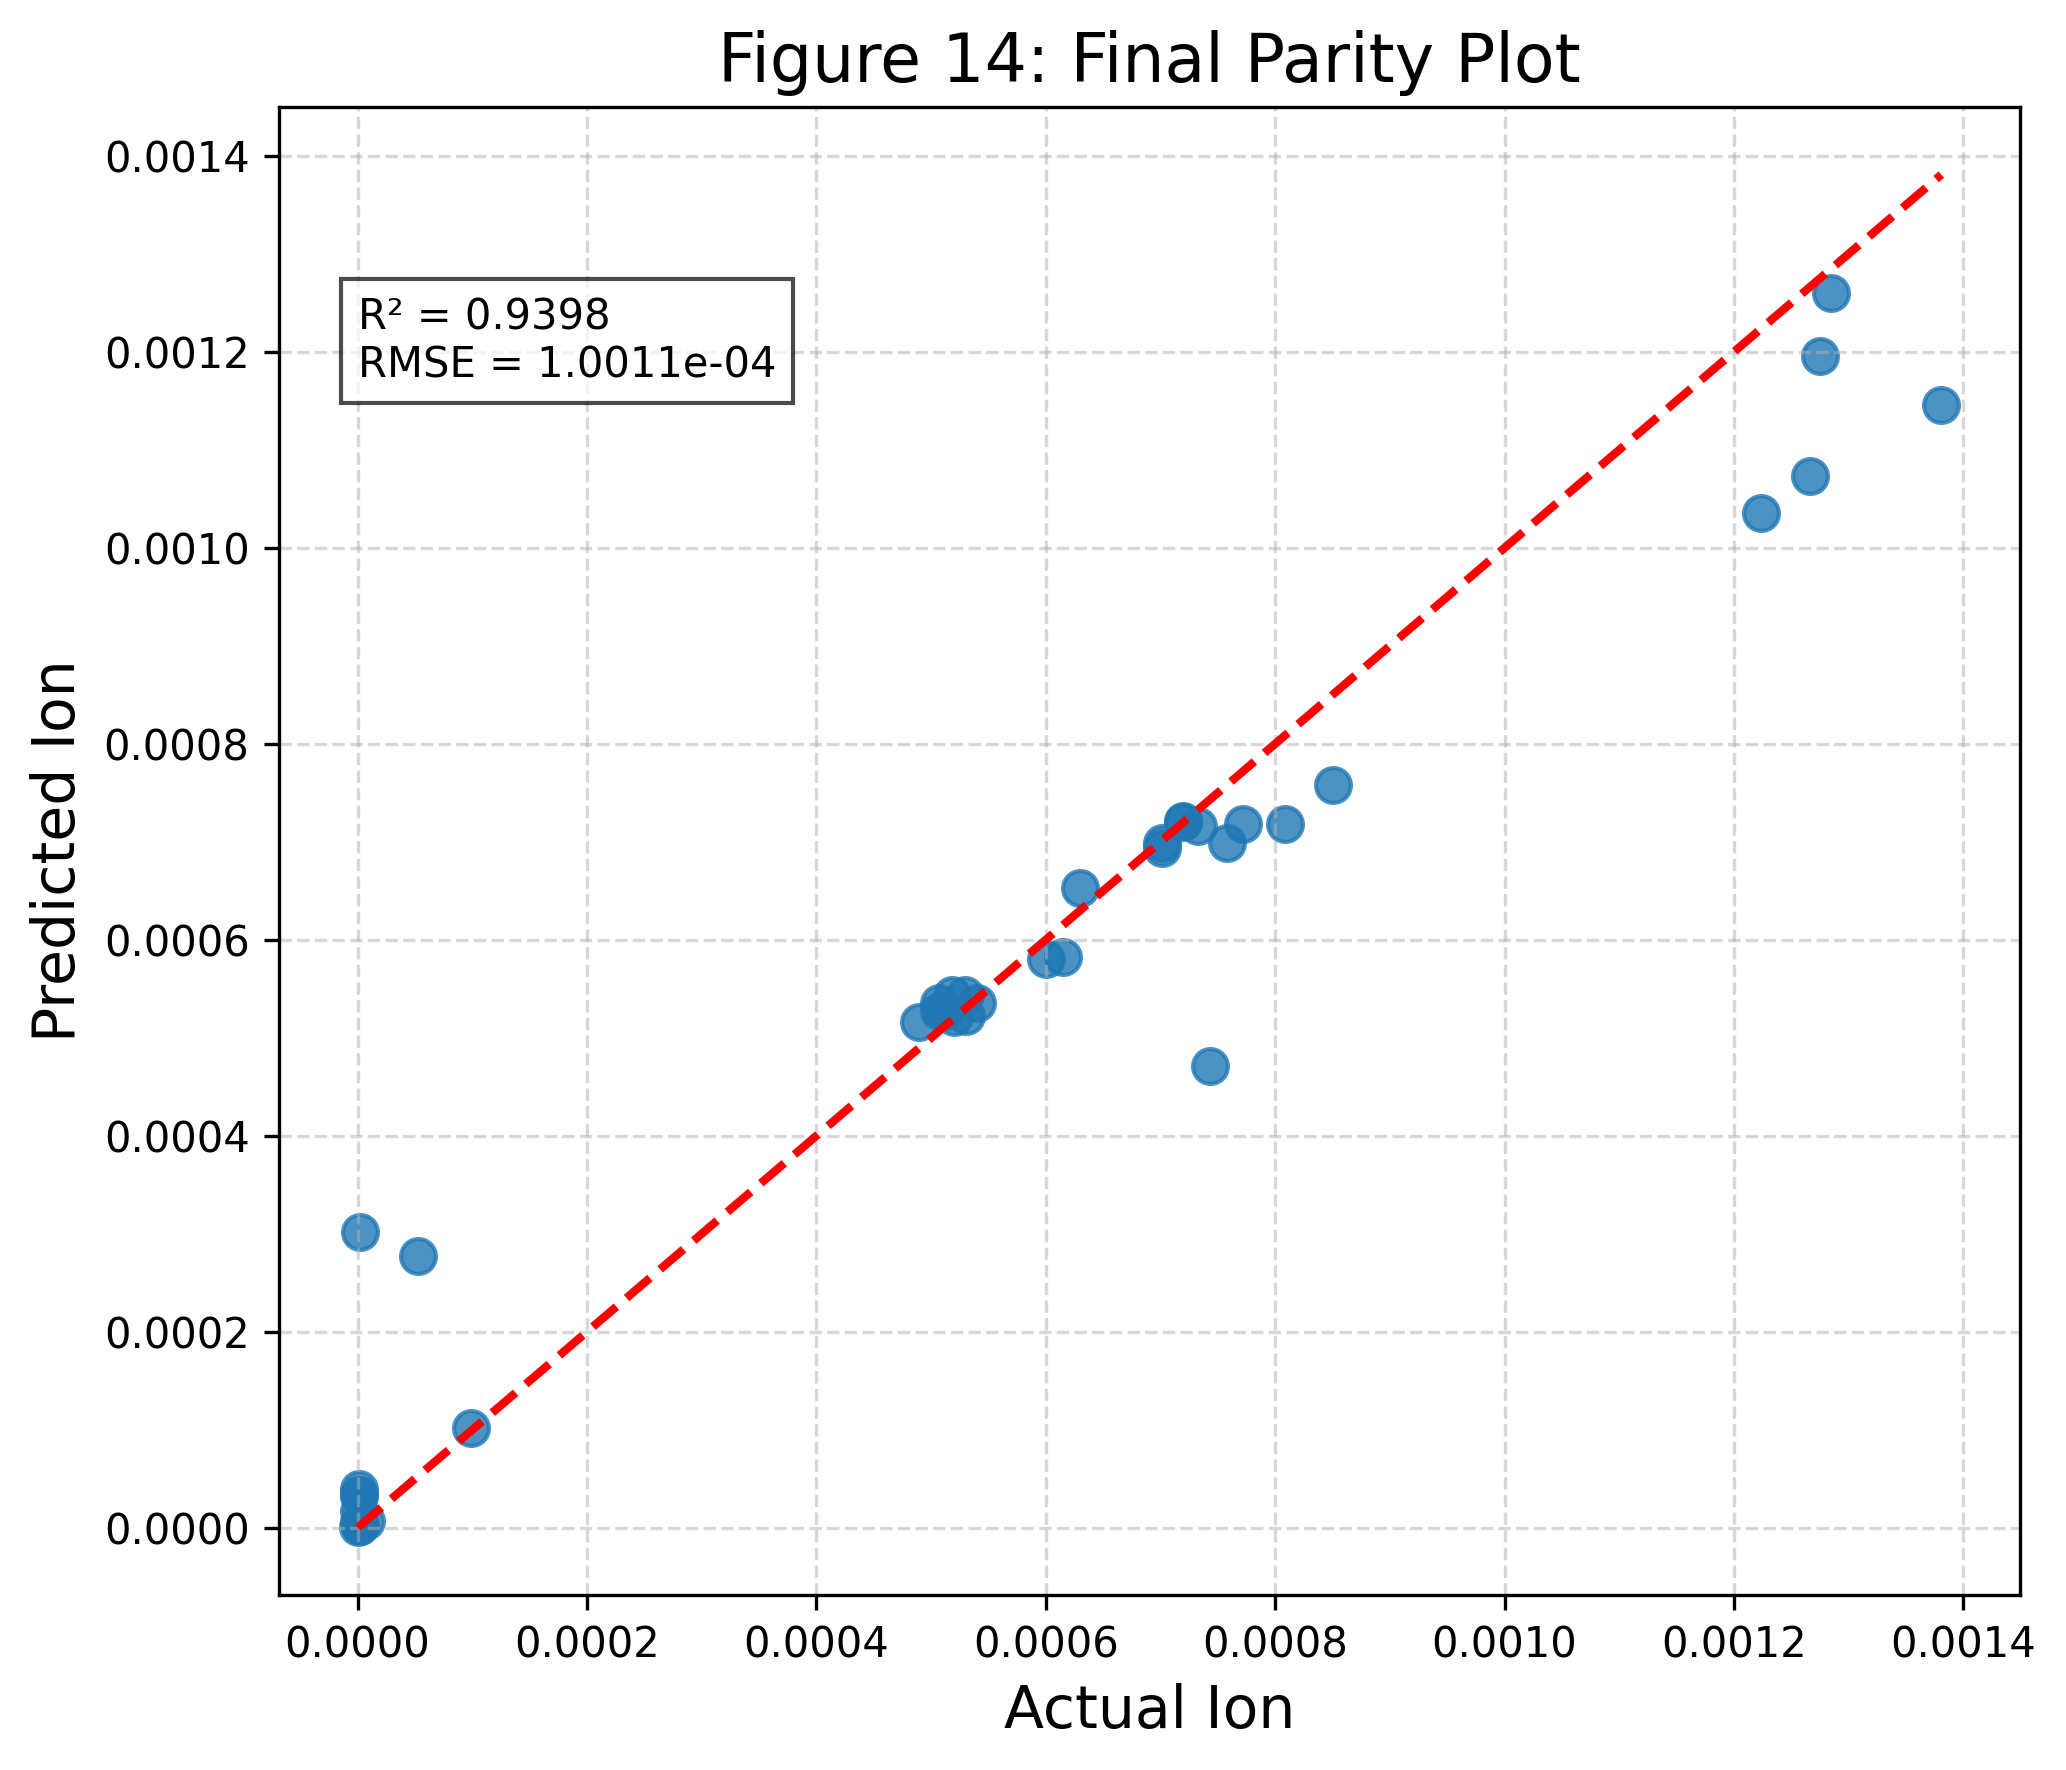

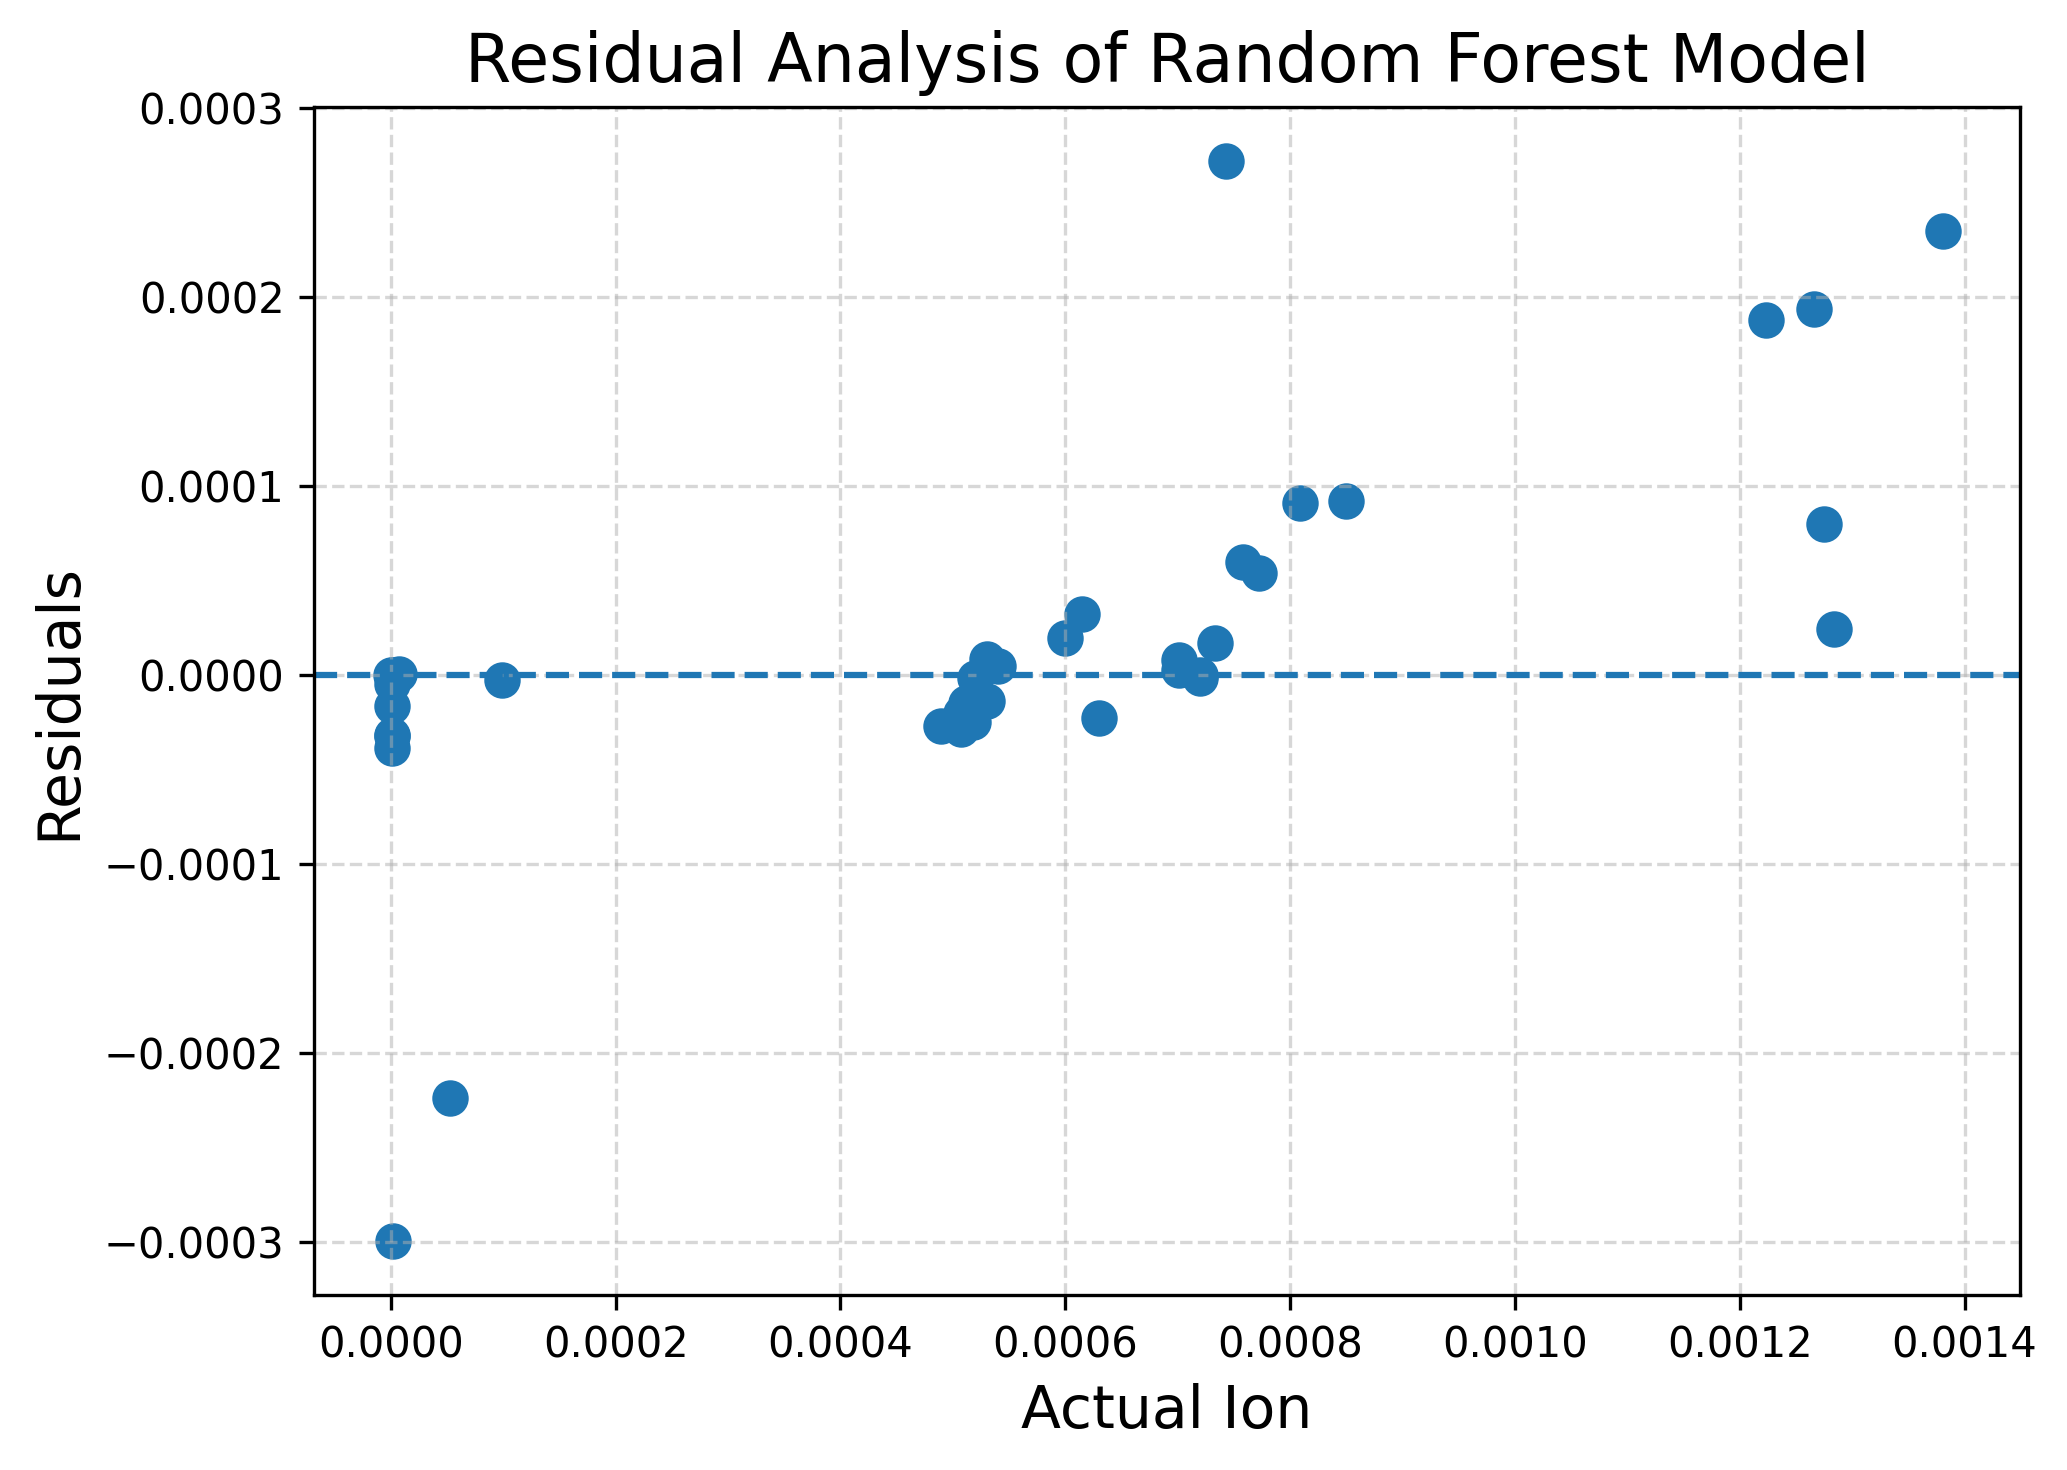


All analysis complete. Journal-ready.


In [2]:
# ======================================================
# GAA FET Transport + ML Hybrid Framework (JOURNAL READY++)
# ======================================================

# !pip install seaborn scikit-learn matplotlib pandas numpy shap xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# =============================
# FIX RANDOMNESS (REPRODUCIBLE RESULTS)
# =============================
np.random.seed(42)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBRegressor
import shap

# =============================
# GLOBAL PLOT SETTINGS
# =============================
mpl.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'figure.dpi': 300,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.5
})

# =============================
# 1. LOAD DATASET
# =============================
url = "https://raw.githubusercontent.com/MonikSense/GAAFET/refs/heads/main/GAA%20Dataset%20Final7.csv"
df = pd.read_csv(url)

df.columns = df.columns.str.strip()

df.rename(columns={
    'Gate Self aligned': 'Gate',
    'Channel direction': 'Direction',
    'Lg (nm)': 'Lg',
    'Wns/Dnw (nm)': 'W',
    'SS (mV/dec)': 'SS',
    'Ion (A/um)': 'Ion'
}, inplace=True)

# =============================
# 2. MONTE CARLO AUGMENTATION
# =============================
num_samples = len(df) * 3
synthetic_data = []

for i in range(num_samples):

    # FIXED RANDOM SAMPLING
    sample = df.sample(1, random_state=42 + i).copy()

    for col in ['Lg', 'W', 'SS', 'Ion', 'Vov']:

        if col in sample.columns:

            # FIXED GAUSSIAN NOISE
            noise = np.random.normal(
                loc=0,
                scale=0.05 * sample[col].values[0]
            )

            sample[col] += noise

    synthetic_data.append(sample)

synthetic_df = pd.concat(synthetic_data, ignore_index=True)

# Combine original + synthetic
df = pd.concat([df, synthetic_df], ignore_index=True)

# =============================
# 3. FEATURE ENGINEERING
# =============================
df['Aspect_Ratio'] = df['W'] / df['Lg']
df['Electrostatic_Factor'] = df['Lg'] / df['W']
df['Effective_Field'] = df['Vov'] / df['Lg']

# =============================
# 4. DEFINE FEATURES
# =============================
TARGET = 'Ion'

X = df.drop([TARGET], axis=1)
y = df[TARGET]

# =============================
# 5. SCALING + SPLIT
# =============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# =============================
# 6. MODELS
# =============================
models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    "KNN": KNeighborsRegressor(),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

results_summary = []

# =============================
# MODEL TRAINING
# =============================
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results_summary.append([name, r2, rmse])

    # =============================
    # PARITY PLOT
    # =============================
    plt.figure(figsize=(6,5))

    plt.scatter(
        y_test,
        y_pred,
        s=60,
        alpha=0.8
    )

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        'r--'
    )

    plt.xlabel("Actual Ion")
    plt.ylabel("Predicted Ion")
    plt.title(f"{name} Model")

    plt.tight_layout()
    plt.show()

# =============================
# MODEL COMPARISON TABLE
# =============================
results_df = pd.DataFrame(
    results_summary,
    columns=["Model", "R2", "RMSE"]
)

print("\nModel Comparison:")
print(results_df)

# =============================
# 7. CLASSIFICATION + FIGURE 10
# =============================
threshold = df['Ion'].median()

df['Ion_Class'] = (
    df['Ion'] > threshold
).astype(int)

X_cls = df.drop(
    ['Ion', 'Ion_Class'],
    axis=1
)

y_cls = df['Ion_Class']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42
)

clf = RandomForestClassifier(
    random_state=42
)

clf.fit(X_train_c, y_train_c)

y_pred_c = clf.predict(X_test_c)

print(
    "\nClassification Accuracy:",
    accuracy_score(y_test_c, y_pred_c)
)

# =============================
# FIGURE 10: CONFUSION MATRIX
# =============================
cm = confusion_matrix(y_test_c, y_pred_c)

fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay(
    cm,
    display_labels=["Low Ion", "High Ion"]
).plot(
    ax=ax,
    cmap='Blues'
)

plt.title("Figure 10: Confusion Matrix")

plt.tight_layout()
plt.show()

# =============================
# 8. CORRELATION MATRIX
# =============================
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

# =============================
# 9. FEATURE IMPORTANCE
# =============================
rf_model = models["Random Forest"]

importance = rf_model.feature_importances_

features = X.columns

sorted_idx = np.argsort(importance)

plt.figure(figsize=(7,5))

plt.barh(
    features[sorted_idx],
    importance[sorted_idx]
)

plt.title("Feature Importance")

plt.tight_layout()
plt.show()

# =============================
# 10. SHAP ANALYSIS
# =============================
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=features
)

# =============================
# 11. TRANSPORT ANALYSIS
# =============================

# Ion vs Lg
plt.figure(figsize=(6,5))

plt.scatter(df['Lg'], df['Ion'])

plt.xlabel("Lg")
plt.ylabel("Ion")
plt.title("Ion vs Lg")

plt.tight_layout()
plt.show()

# SS vs W
plt.figure(figsize=(6,5))

plt.scatter(df['W'], df['SS'])

plt.xlabel("W")
plt.ylabel("SS")
plt.title("SS vs W")

plt.tight_layout()
plt.show()

# Ion vs SS
plt.figure(figsize=(6,5))

plt.scatter(df['SS'], df['Ion'])

plt.xlabel("SS")
plt.ylabel("Ion")
plt.title("Ion vs SS")

plt.tight_layout()
plt.show()

# =============================
# 12. DISTRIBUTION
# =============================
plt.figure(figsize=(6,4))

sns.histplot(df['Ion'], kde=True)

plt.title("Distribution of Ion")

plt.tight_layout()
plt.show()

# =============================
# 13. FINAL FIGURE 14
# =============================
y_pred_final = models['Random Forest'].predict(X_test)

r2_final = r2_score(y_test, y_pred_final)

rmse_final = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_final
    )
)

plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    y_pred_final,
    s=70,
    alpha=0.8
)

min_val = min(
    y_test.min(),
    y_pred_final.min()
)

max_val = max(
    y_test.max(),
    y_pred_final.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Ion")
plt.ylabel("Predicted Ion")

plt.title("Figure 14: Final Parity Plot")

plt.text(
    min_val,
    max_val * 0.85,
    f"R² = {r2_final:.4f}\nRMSE = {rmse_final:.4e}",
    bbox=dict(
        facecolor='white',
        alpha=0.7
    )
)

plt.tight_layout()
plt.show()

# =============================
# SAVE RESULTS
# =============================
pred_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted_RF': y_pred_final
})

pred_df.to_csv(
    "prediction_results.csv",
    index=False
)

# =============================
# RESIDUAL ANALYSIS
# =============================
residuals = y_test - y_pred_final

plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    residuals,
    s=60
)

plt.axhline(
    0,
    linestyle='--'
)

plt.xlabel("Actual Ion")
plt.ylabel("Residuals")

plt.title("Residual Analysis of Random Forest Model")

plt.tight_layout()
plt.show()

print("\nAll analysis complete. Journal-ready.")